In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_1 = pd.read_csv("violent_events_1.csv", sep=";", skipinitialspace=True)

In [3]:
df_2 = pd.read_csv("violent_events_2.csv", sep=";", skipinitialspace=True)

In [4]:
df = pd.concat([df_1, df_2])

In [5]:
df.head()

,Country,Admin1,Admin2,ISO3,Admin2 Pcode,Admin1 Pcode,Month,Year,Events,Fatalities
0,Haiti,Ouest,Archaie,HTI,HT0142,HT01,January,2018,0,0
1,Haiti,Nord-Ouest,Mole Saint Nicolas,HTI,HT0931,HT09,January,2018,0,0
2,Haiti,Centre,Hinche,HTI,HT0611,HT06,January,2018,0,0
3,Haiti,Nord,Acul Du Nord,HTI,HT0321,HT03,January,2018,0,0
4,Haiti,Ouest,Port-au-Prince,HTI,HT0111,HT01,January,2018,1,0


In [6]:
df.columns

Index(['Country', 'Admin1', 'Admin2', 'ISO3', 'Admin2 Pcode', 'Admin1 Pcode',
       'Month', 'Year', 'Events', 'Fatalities'],
      dtype='object')

In [7]:
df_year_grouped = df.groupby(['Country', 'Year'])[['Fatalities', 'Events']].sum().reset_index()

In [8]:
df_year_grouped["violence_ratio"] = df_year_grouped["Fatalities"] / df_year_grouped["Events"]

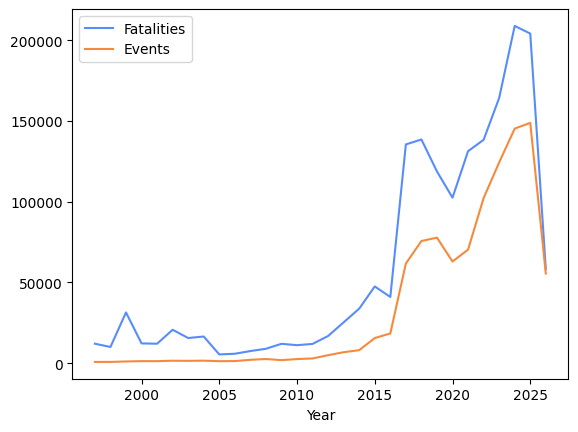

In [9]:
df_year_grouped.groupby('Year')[['Fatalities', 'Events']].sum().plot(kind='line')
plt.show()

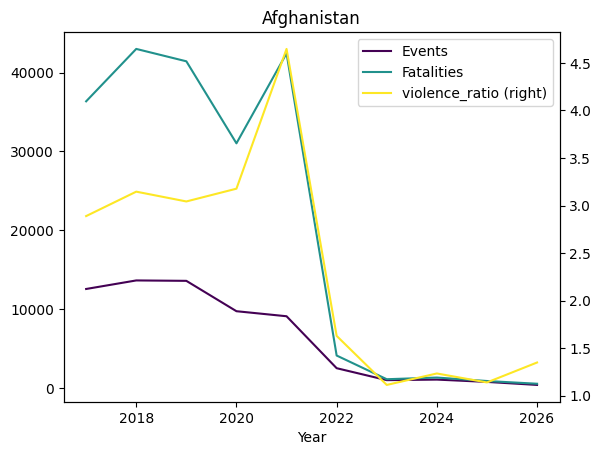

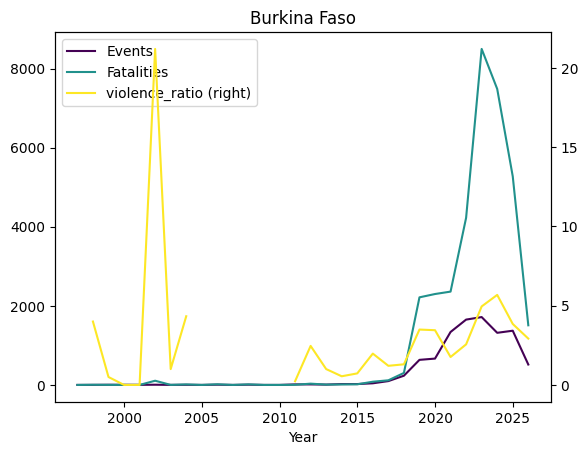

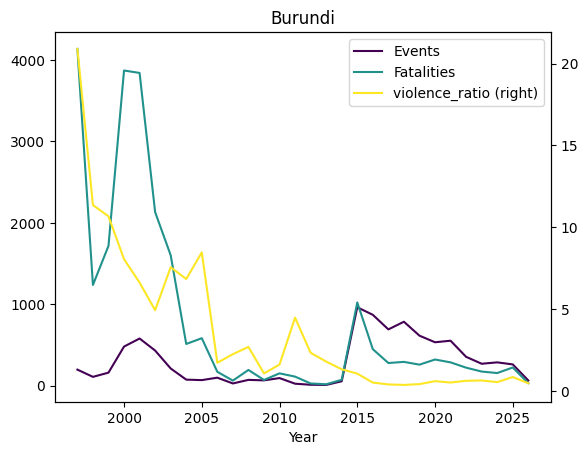

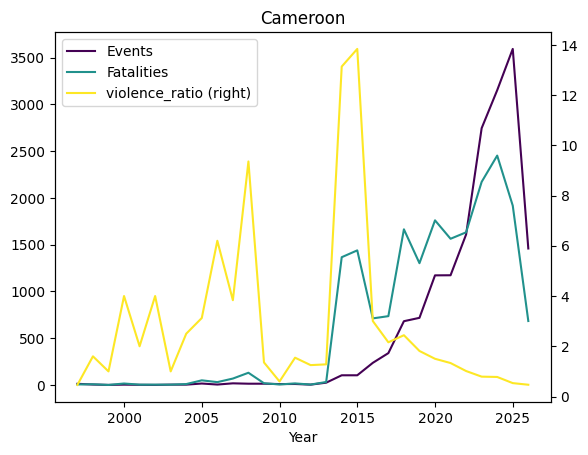

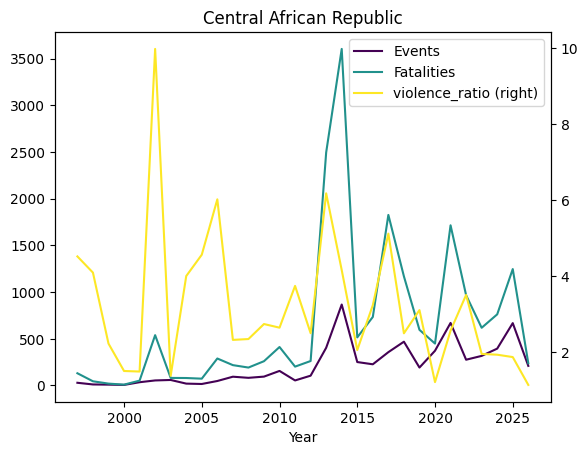

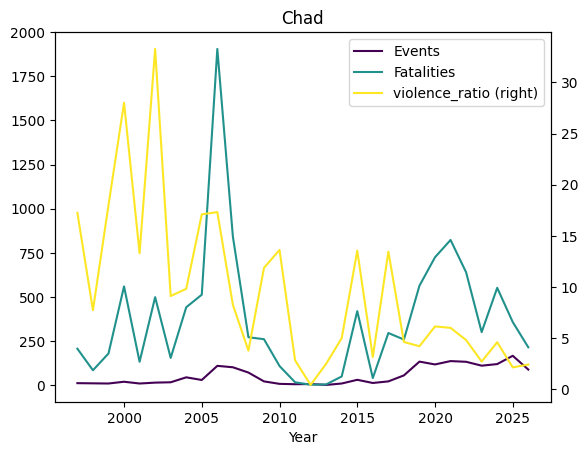

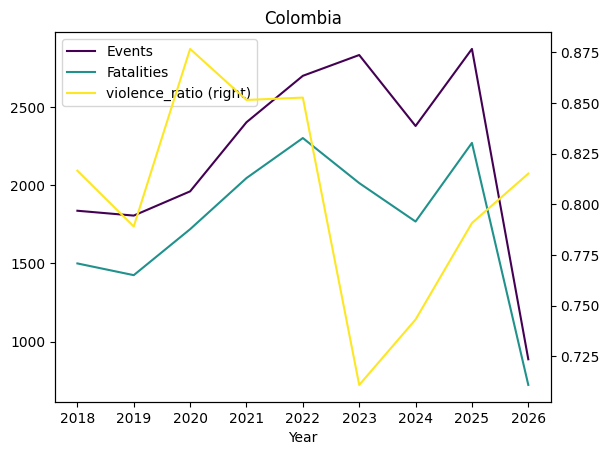

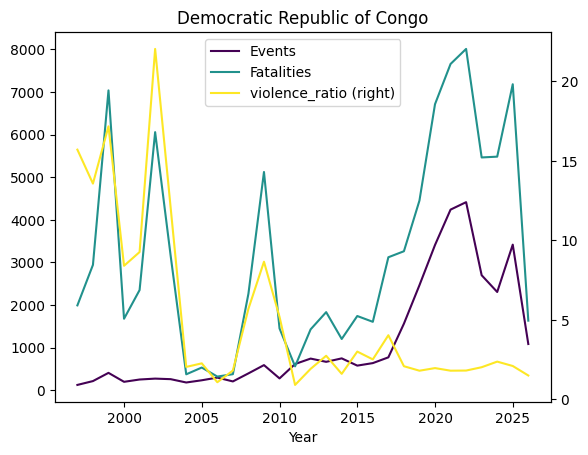

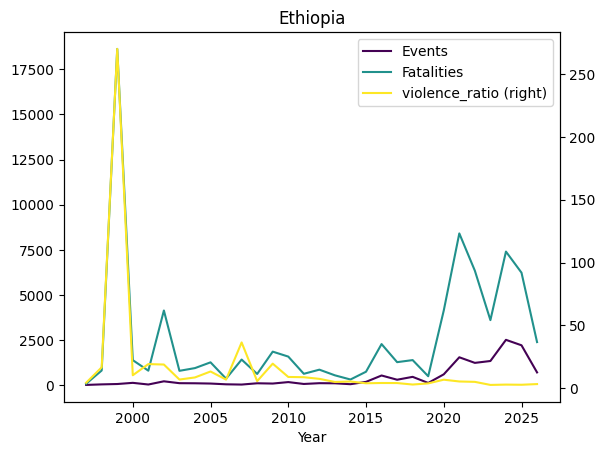

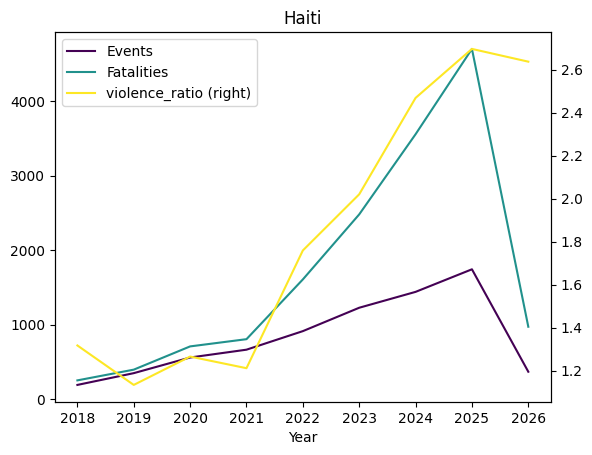

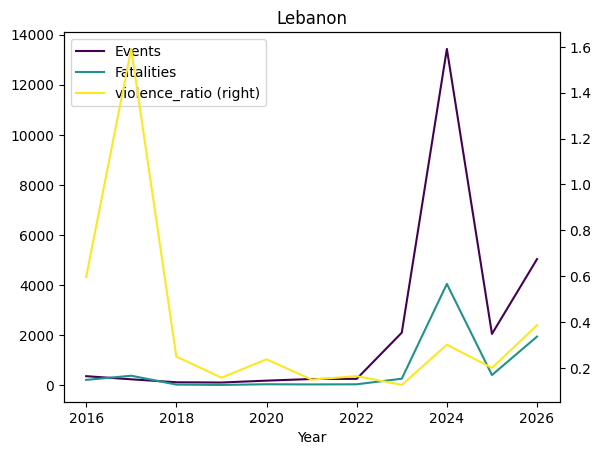

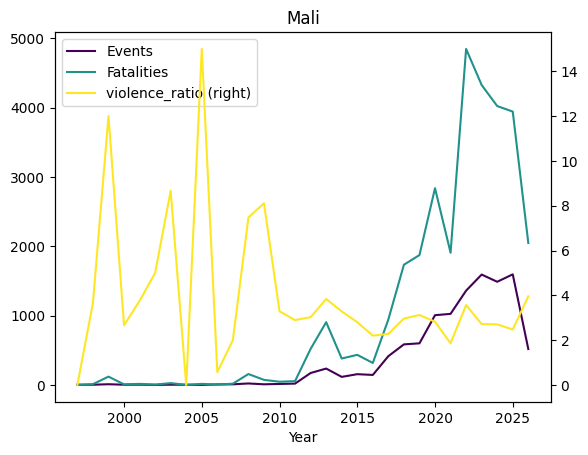

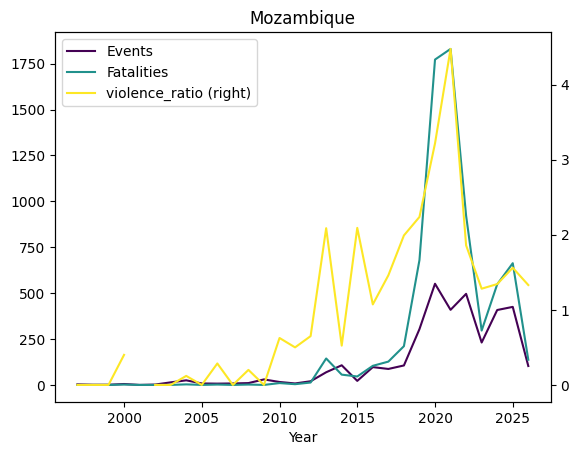

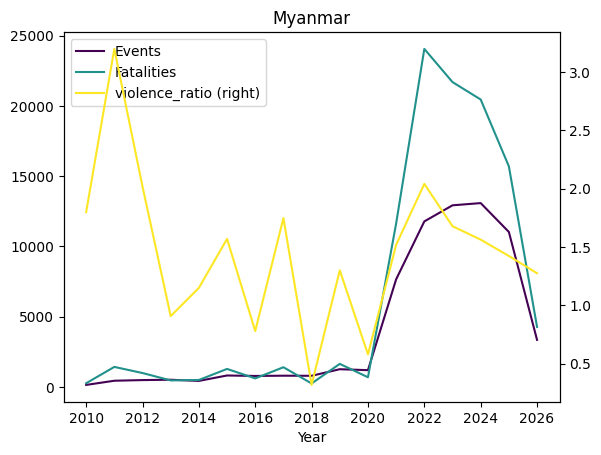

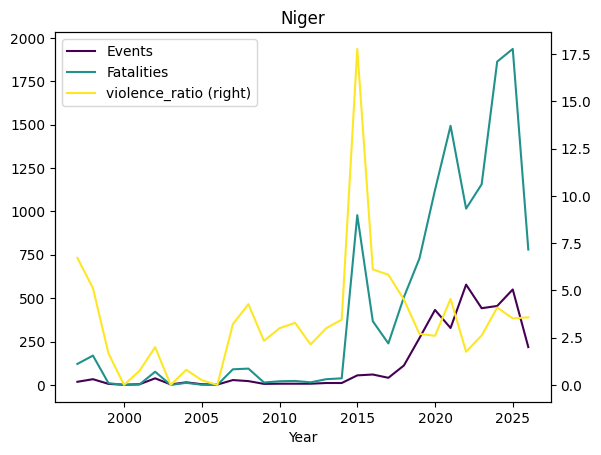

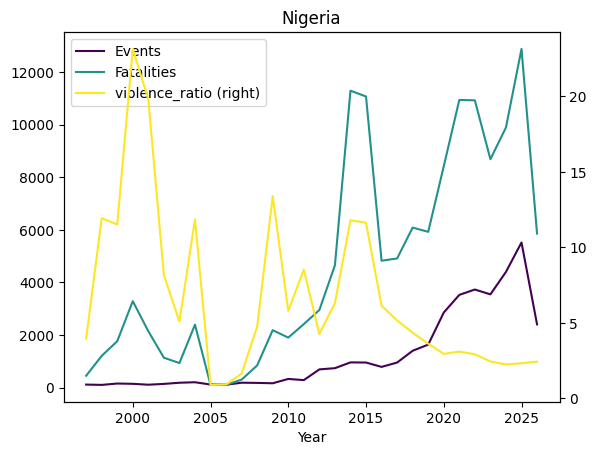

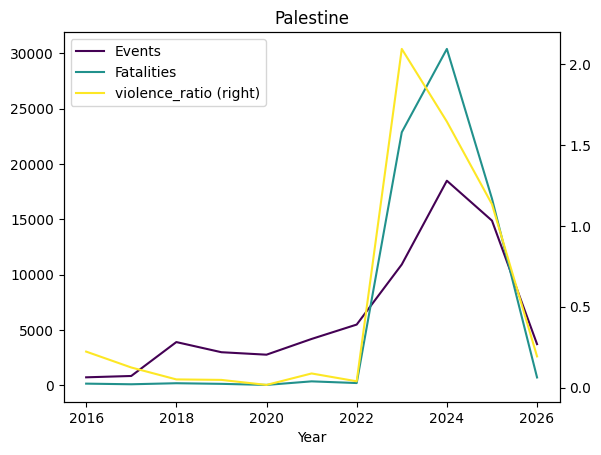

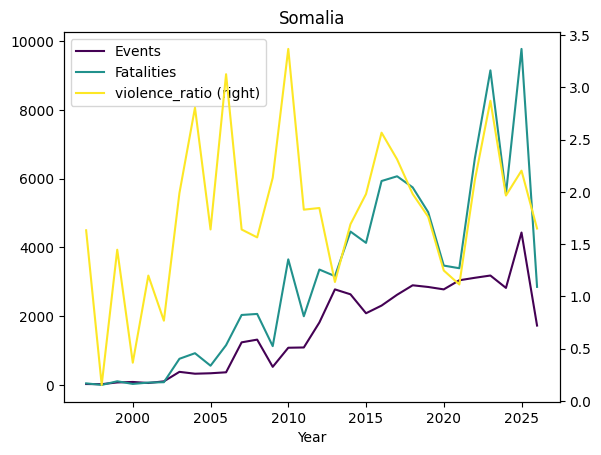

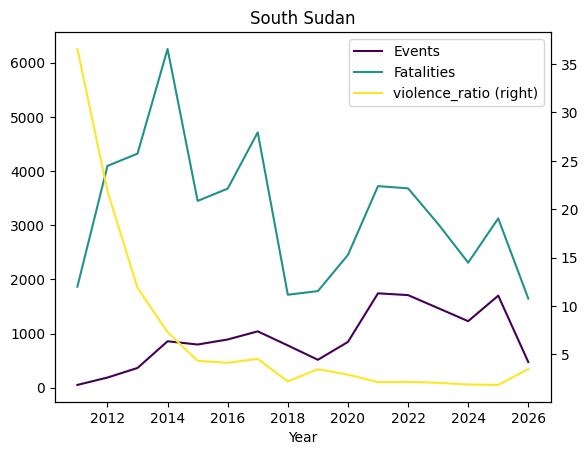

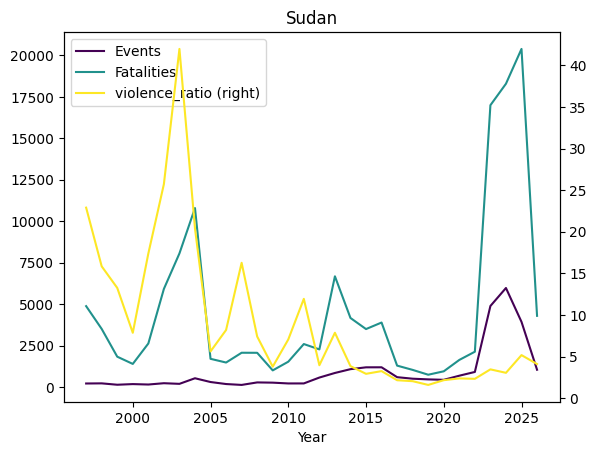

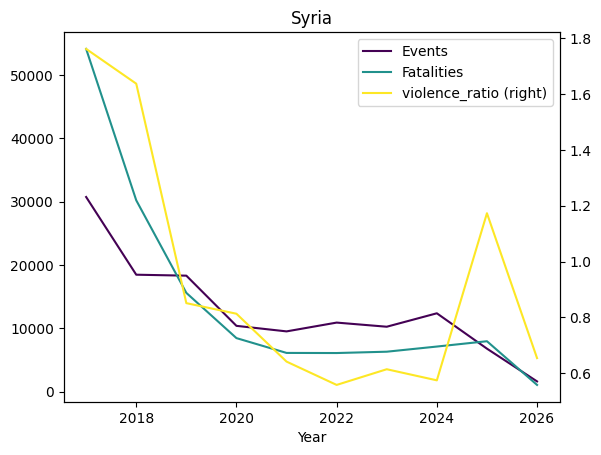

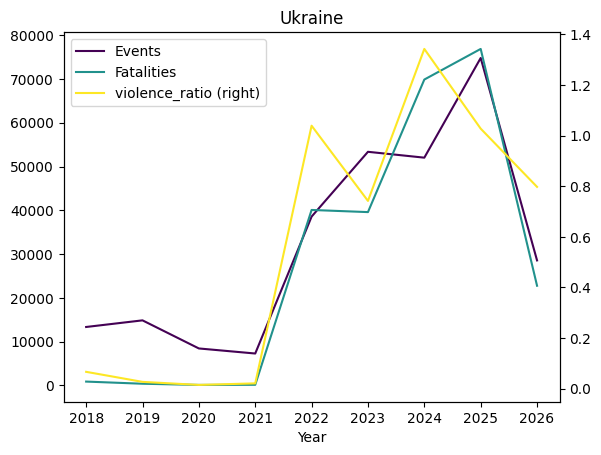

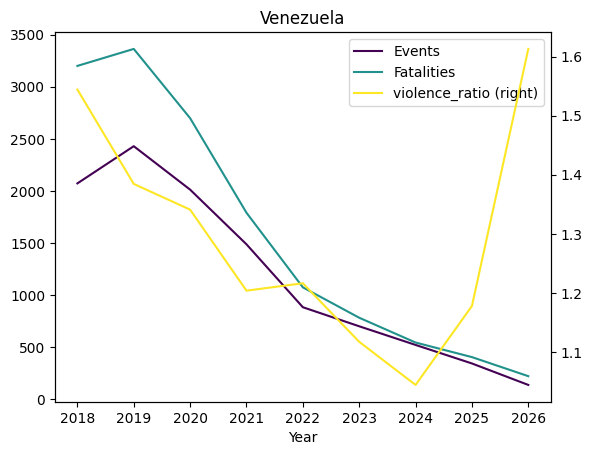

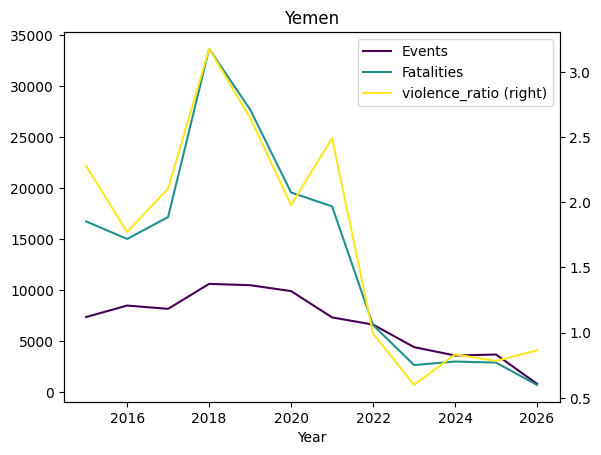

In [10]:
for country in df_year_grouped["Country"].unique():

    # 1. Filter the data EXACTLY ONCE per loop
    country_subset = df_year_grouped[df_year_grouped["Country"] == country]

    # 2. Plot all three columns in a single command.
    # Use secondary_y to assign the fractional ratio to the right-side axis.
    country_subset.plot(
        x="Year",
        y=["Events", "Fatalities", "violence_ratio"],
        kind="line",
        title=country,
        secondary_y=["violence_ratio"], # Isolates the scale of the ratio
        colormap="viridis"
    )

    # 3. Render the combined chart
    plt.show()

In [11]:
df_month_grouped = df.groupby(['Country', 'Year', "Month"])[['Fatalities', 'Events']].sum().reset_index()

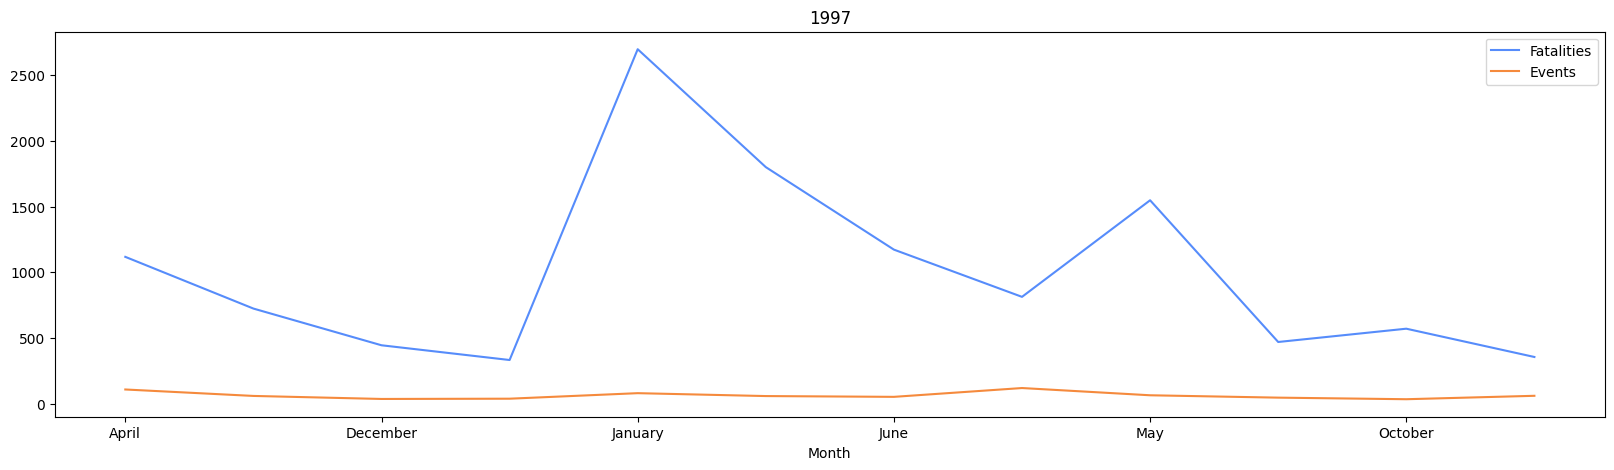

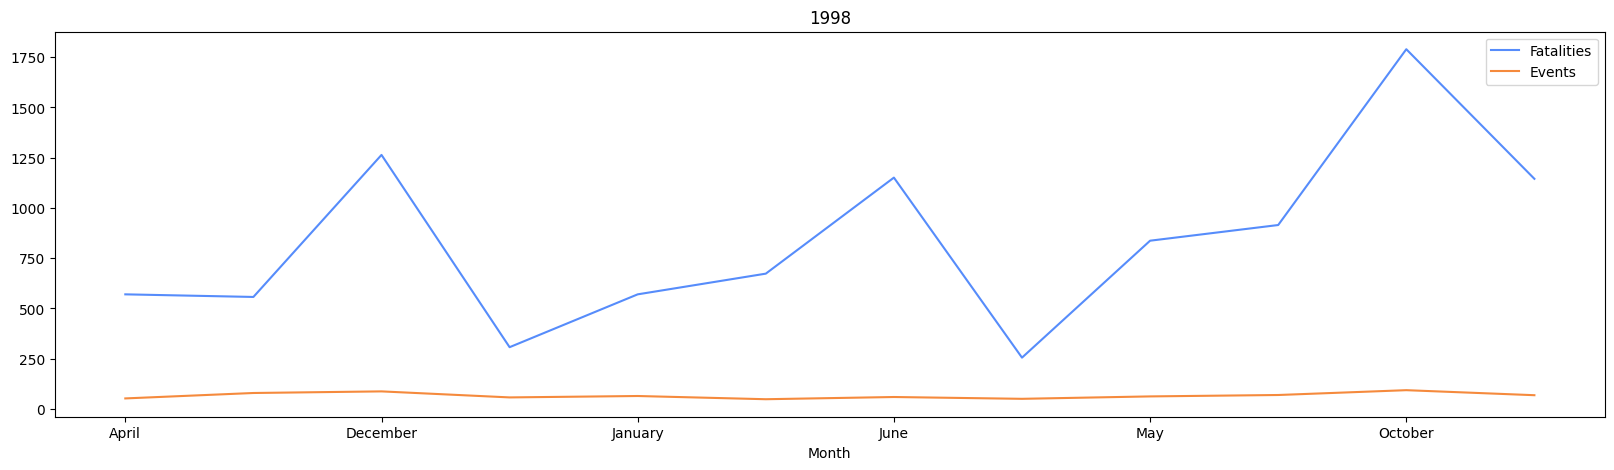

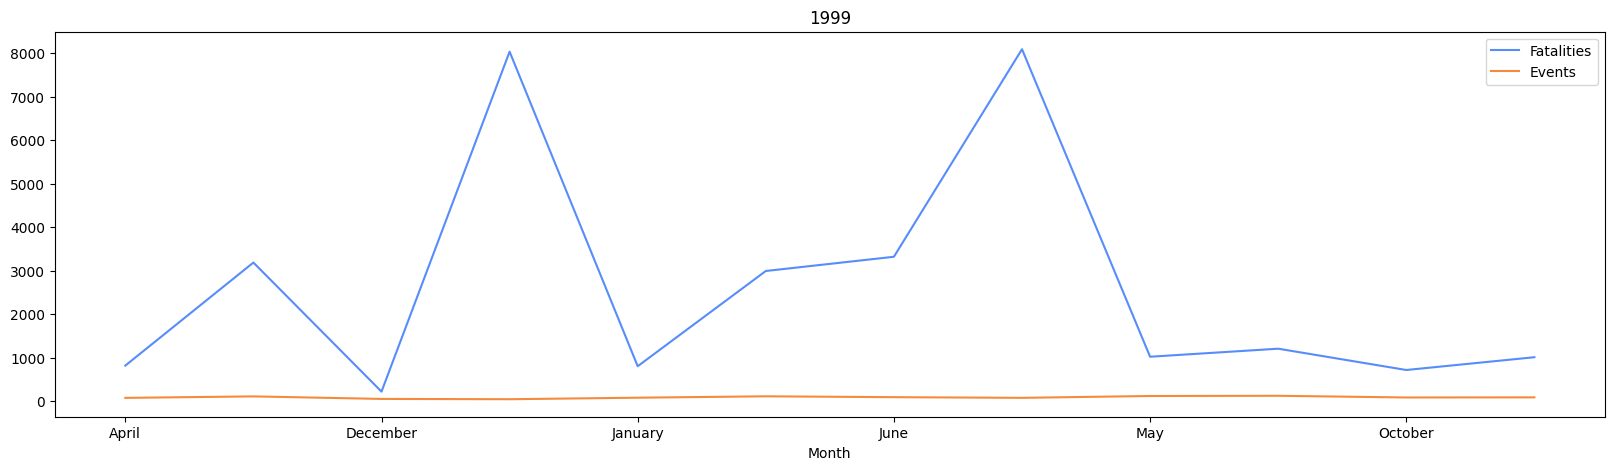

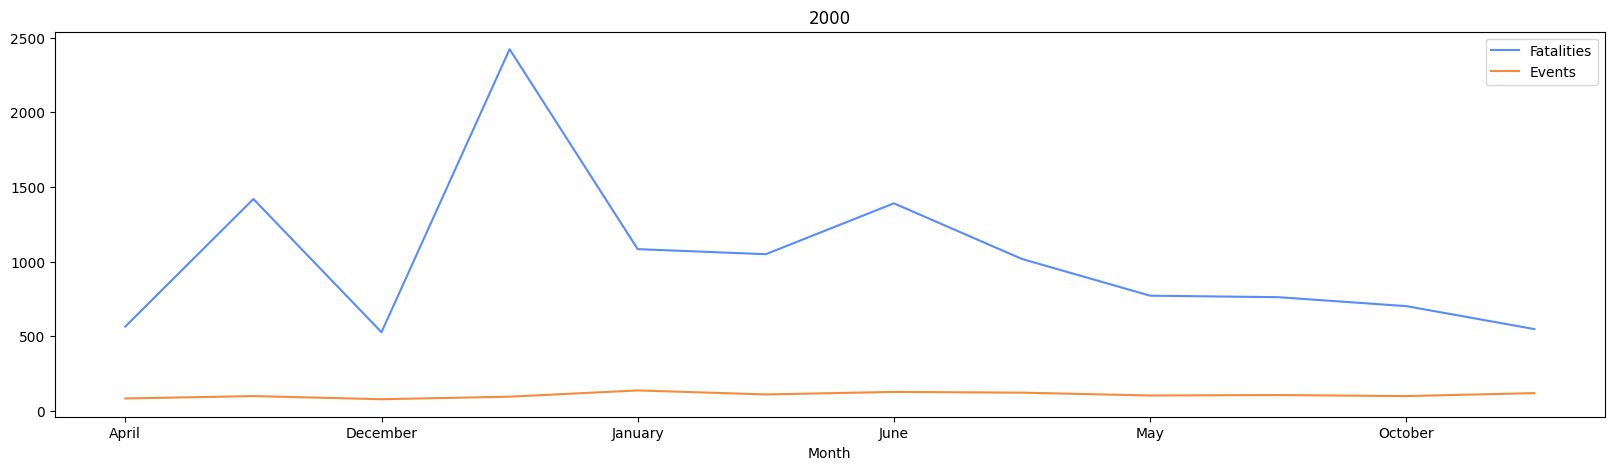

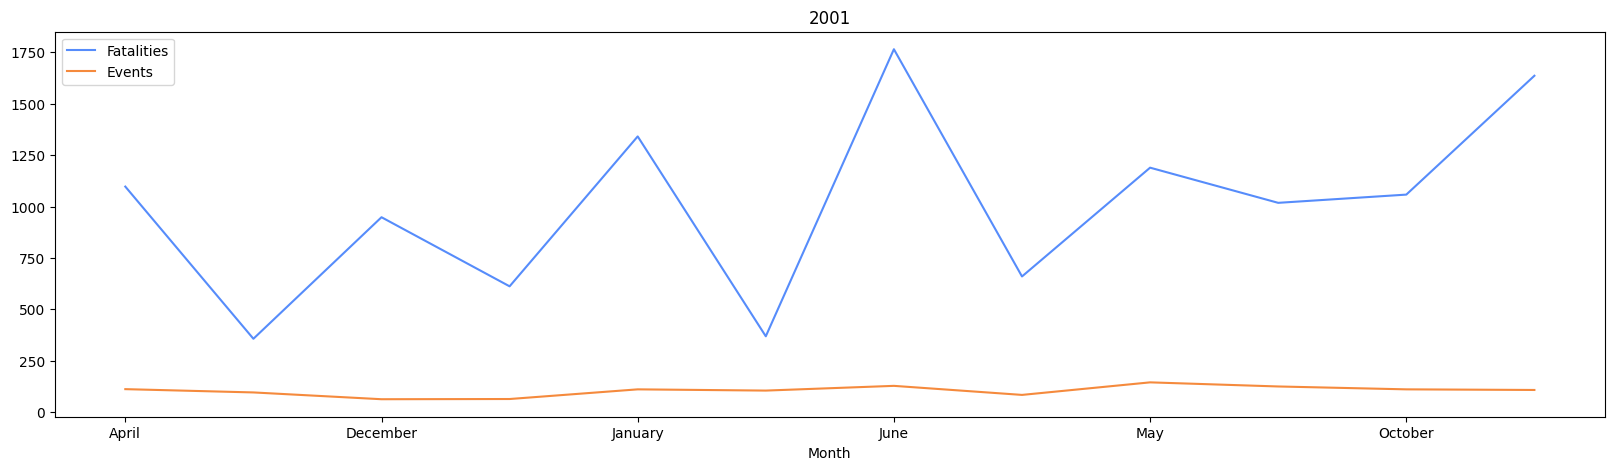

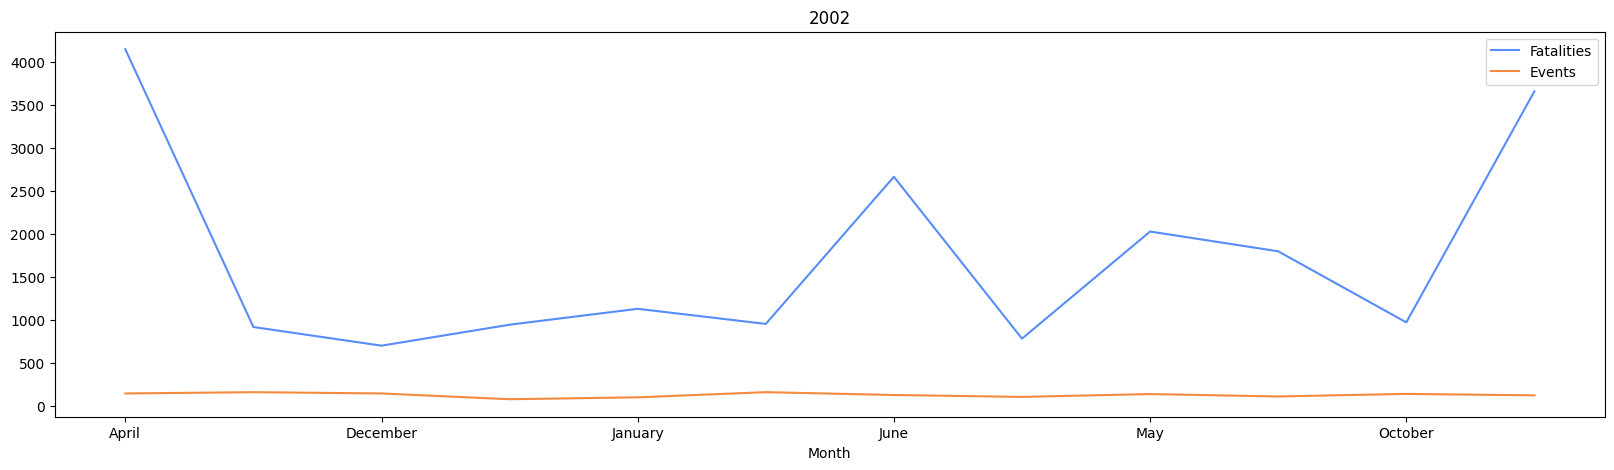

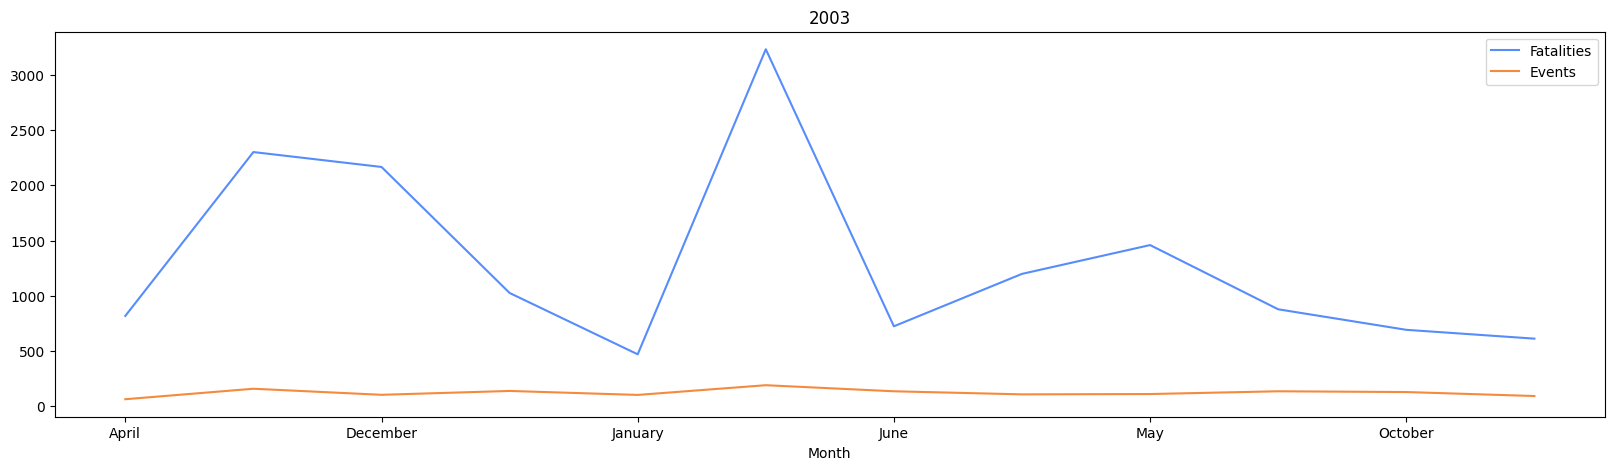

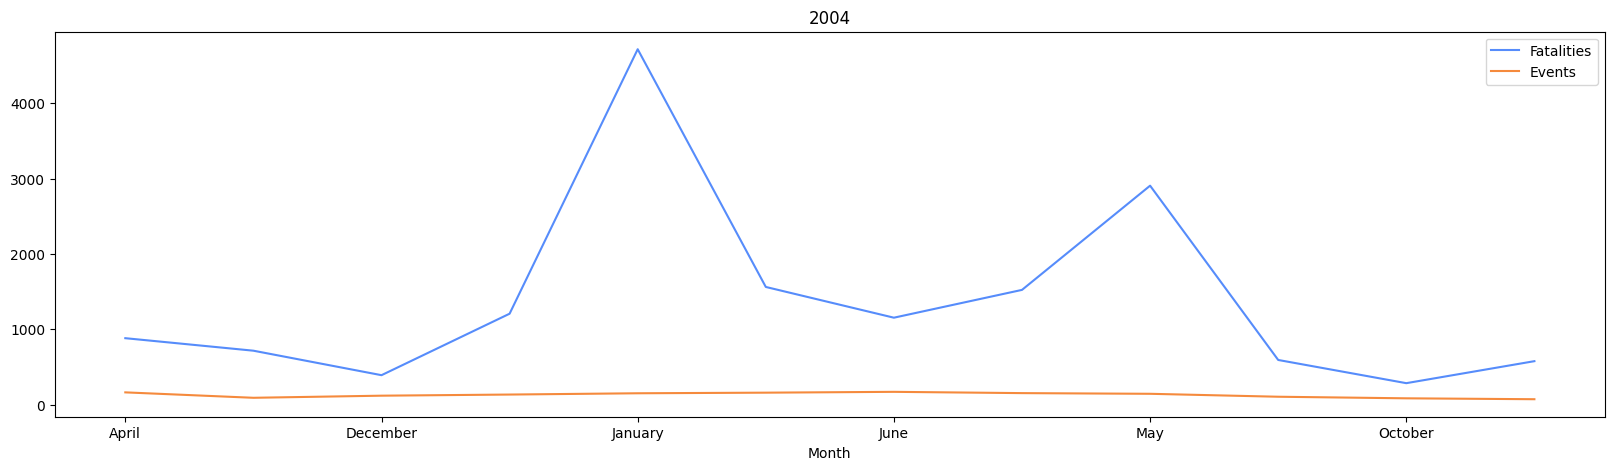

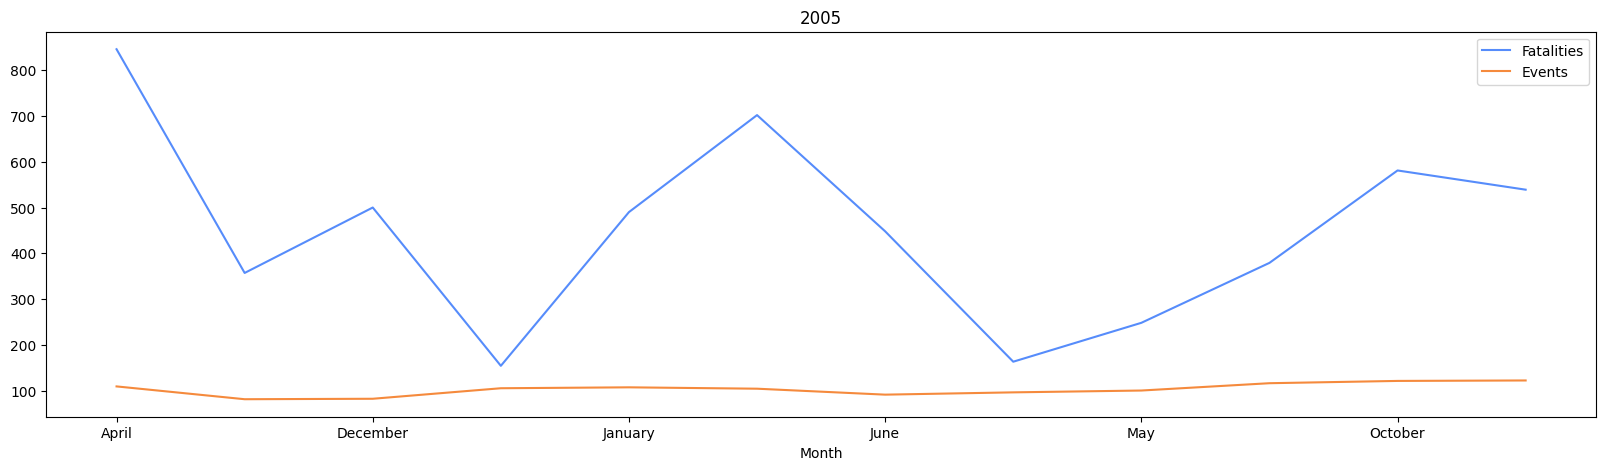

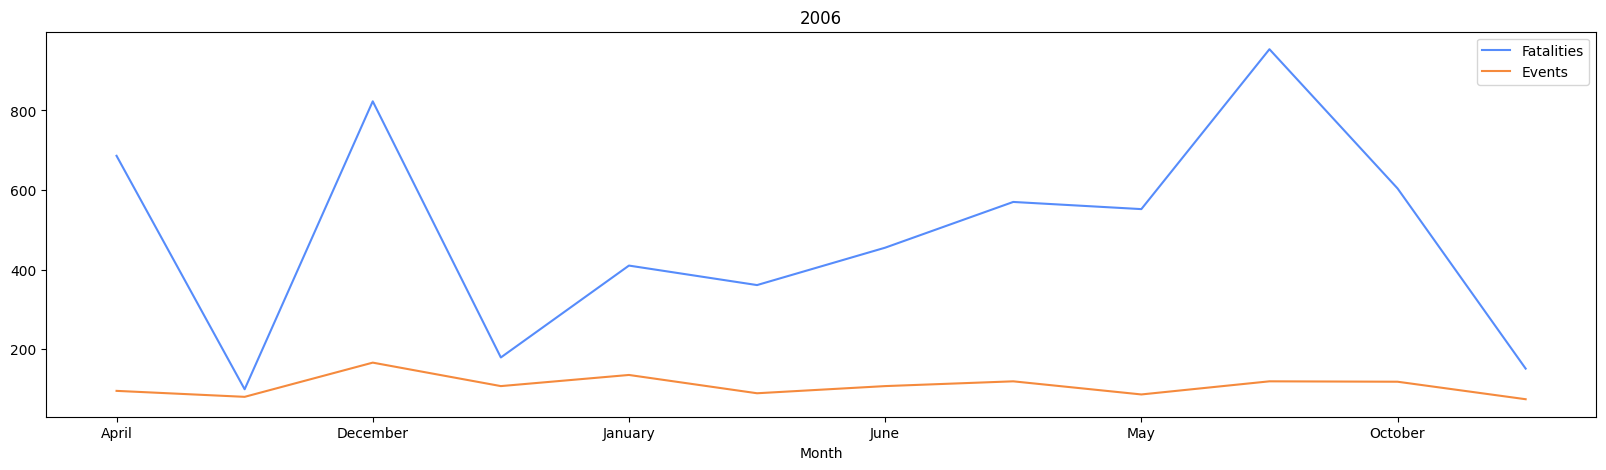

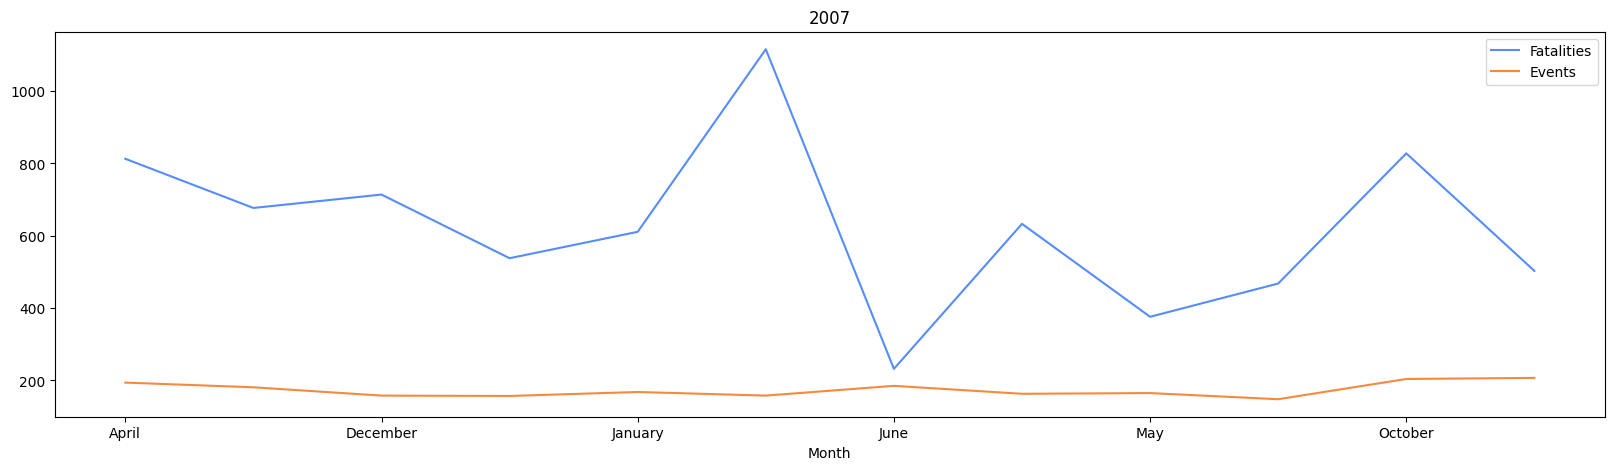

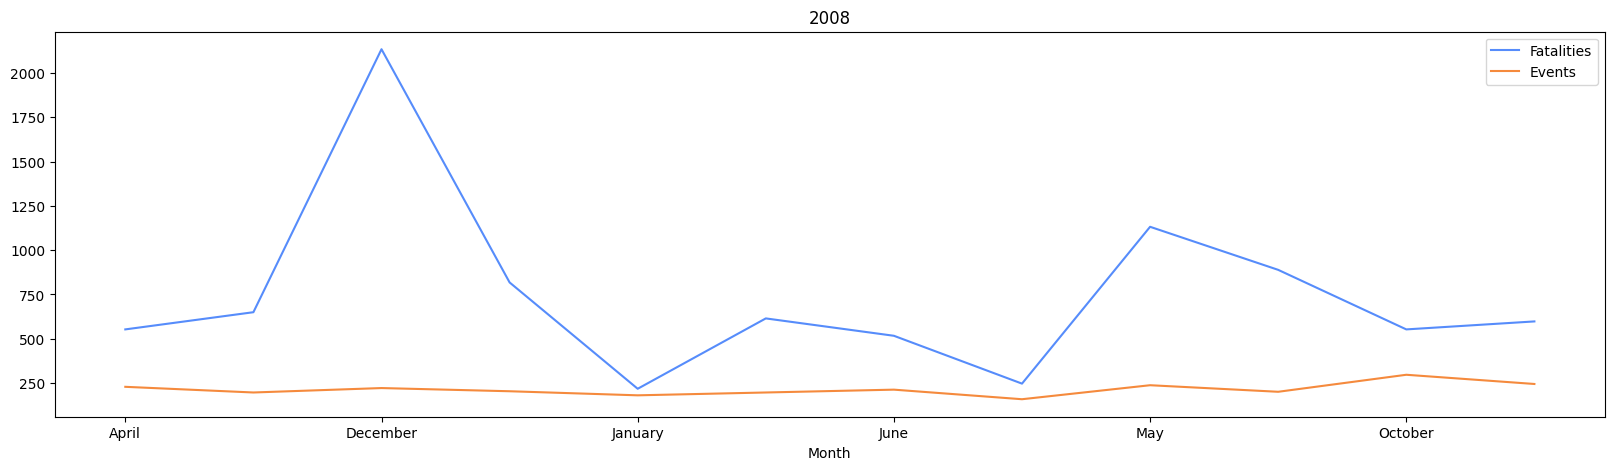

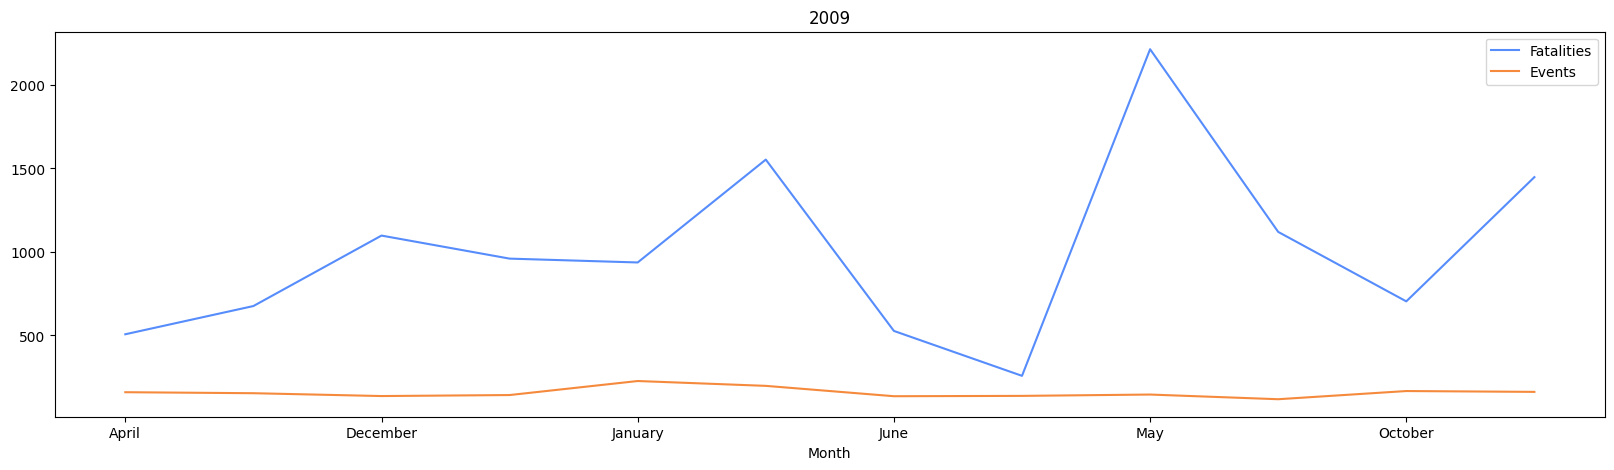

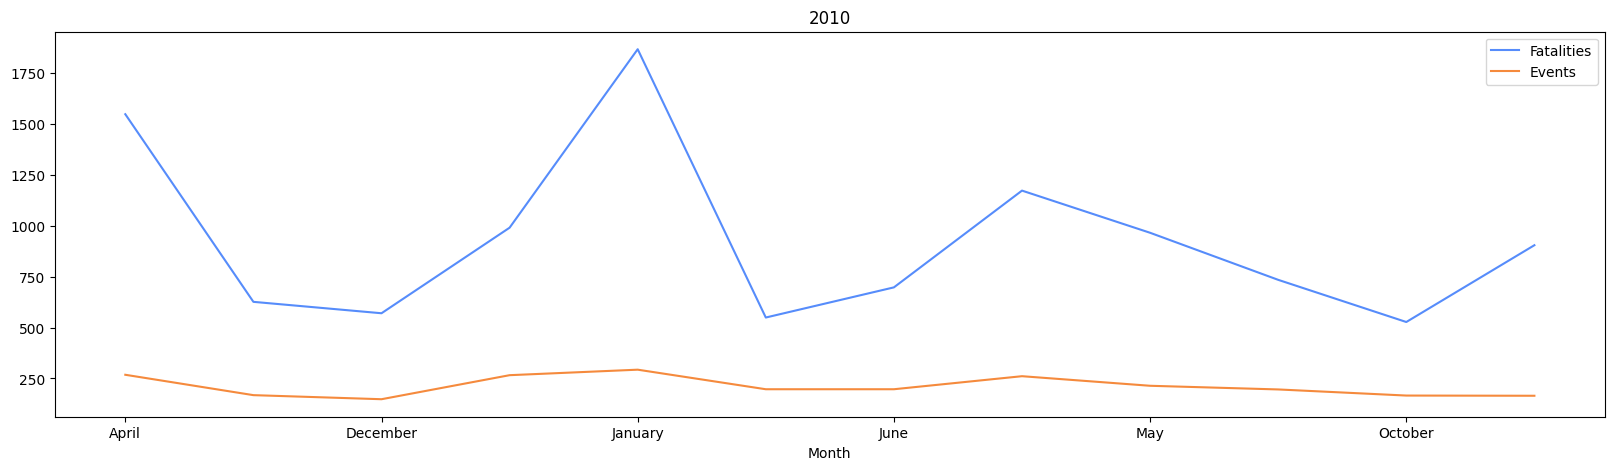

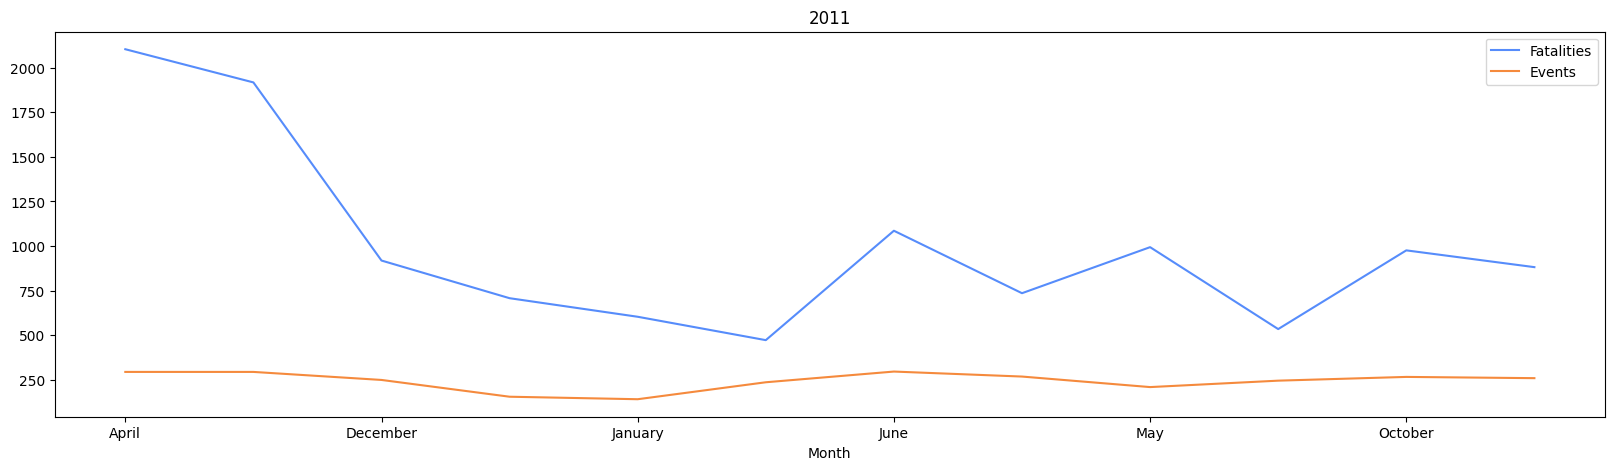

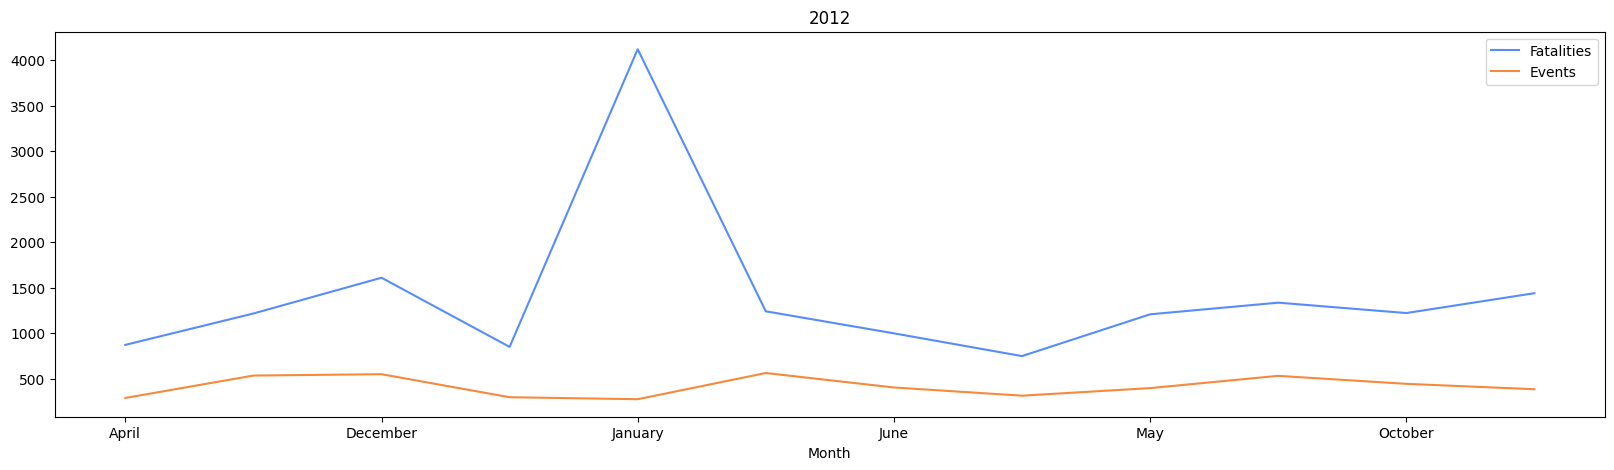

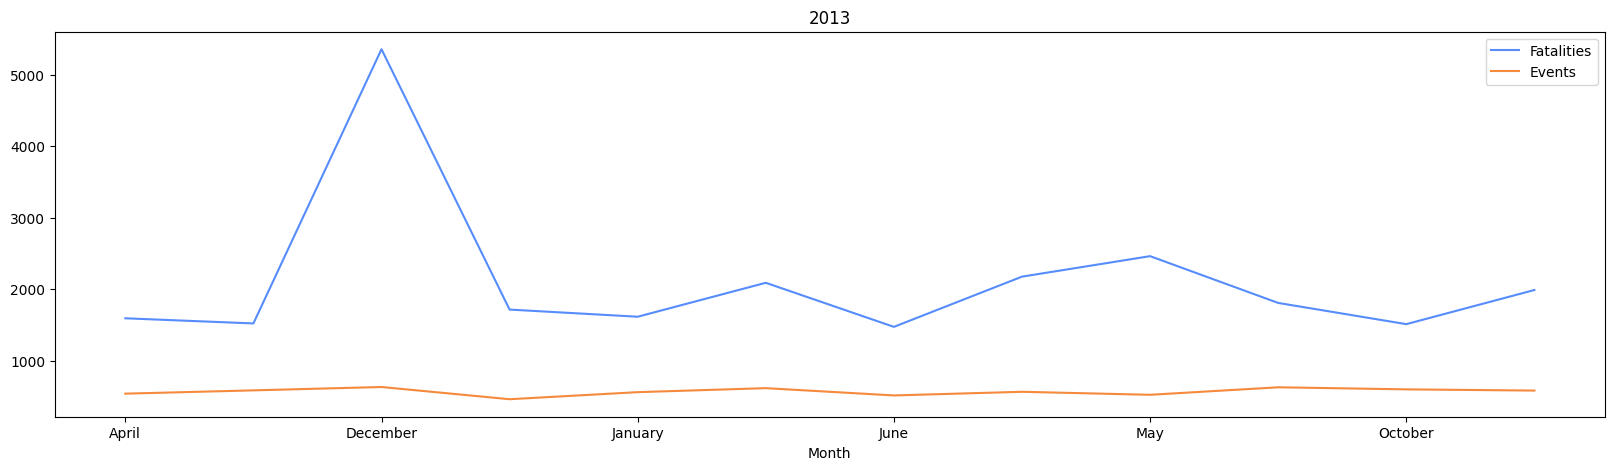

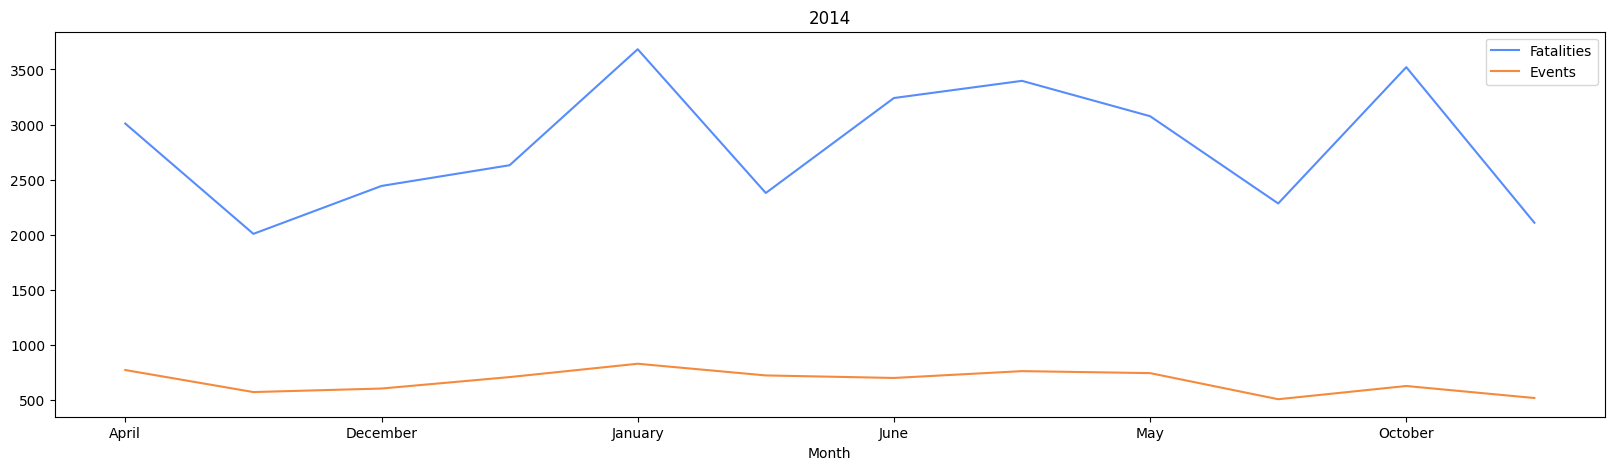

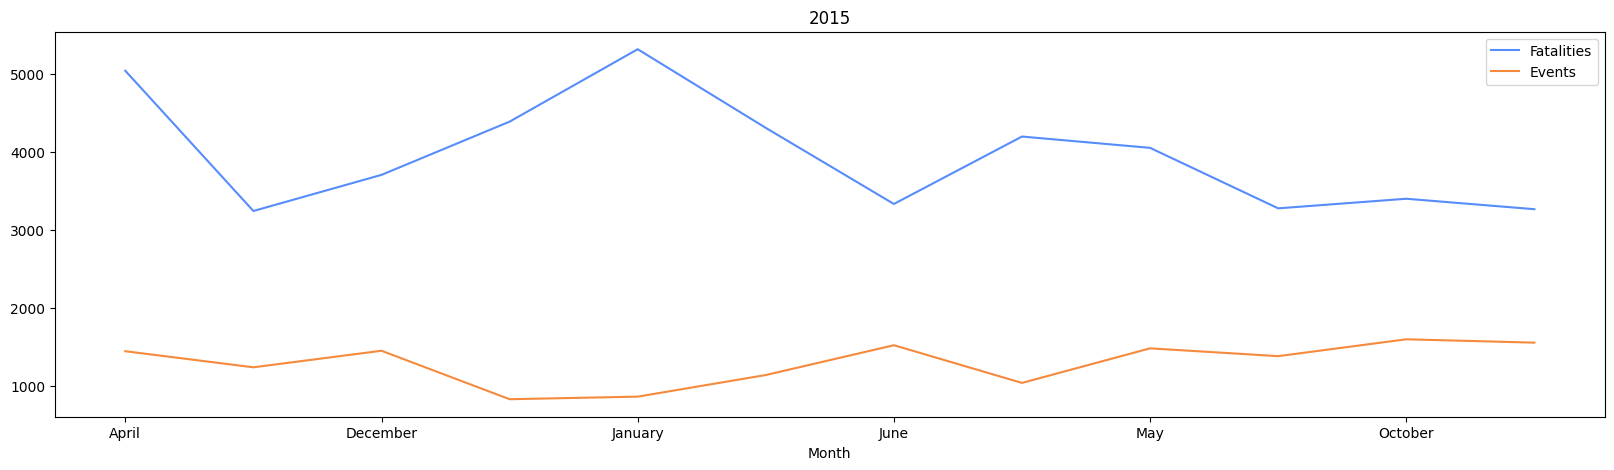

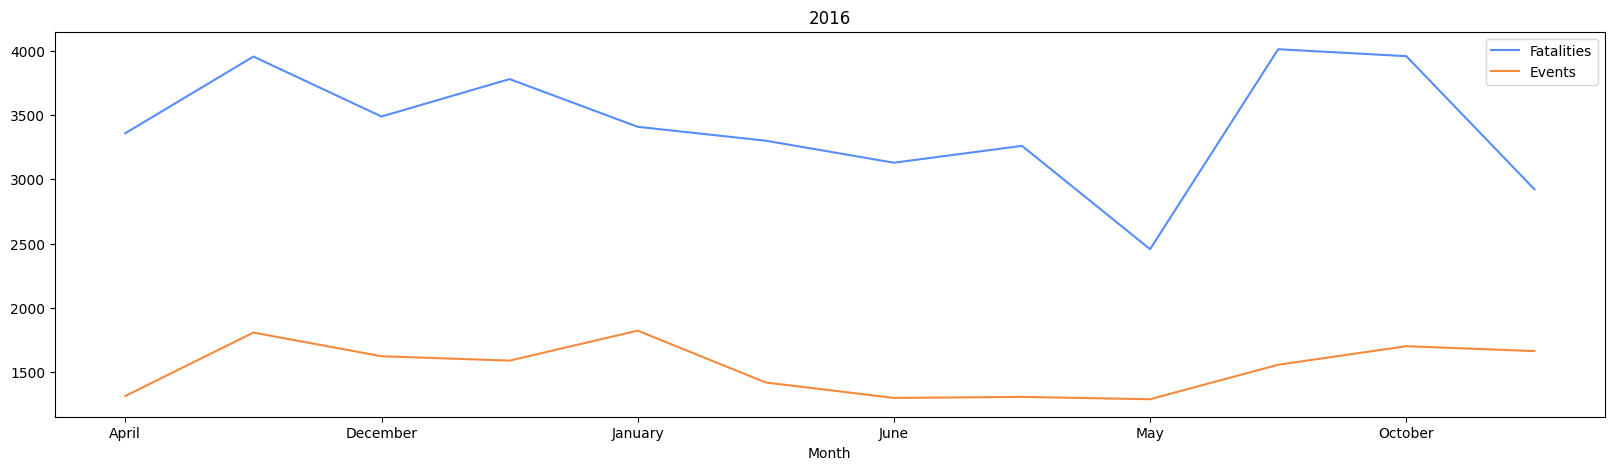

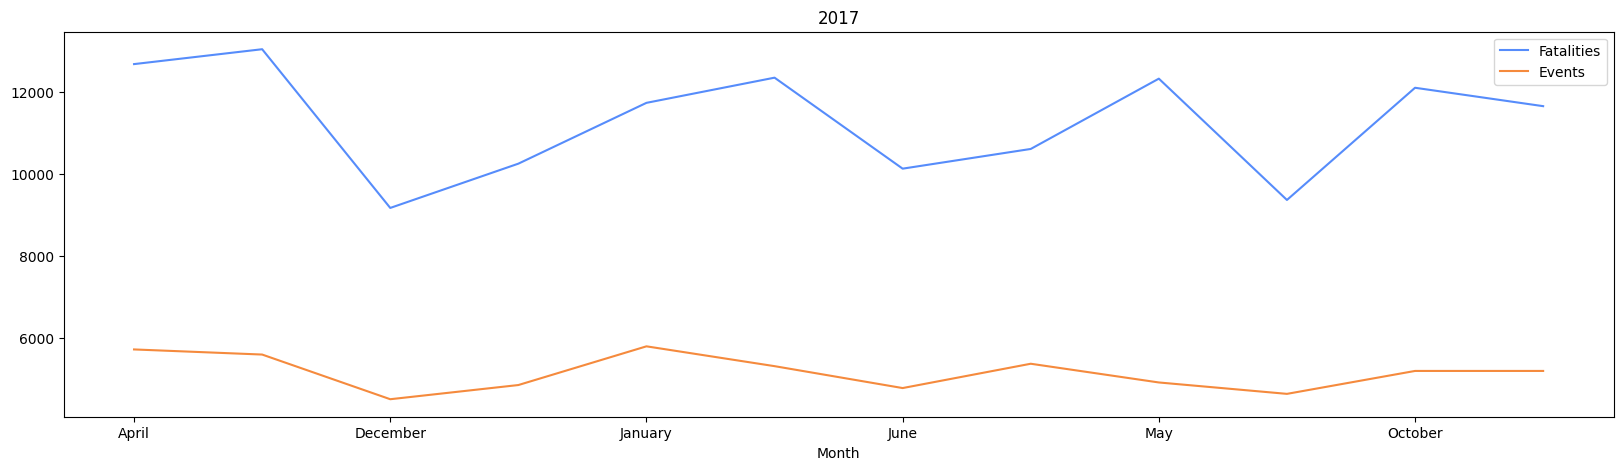

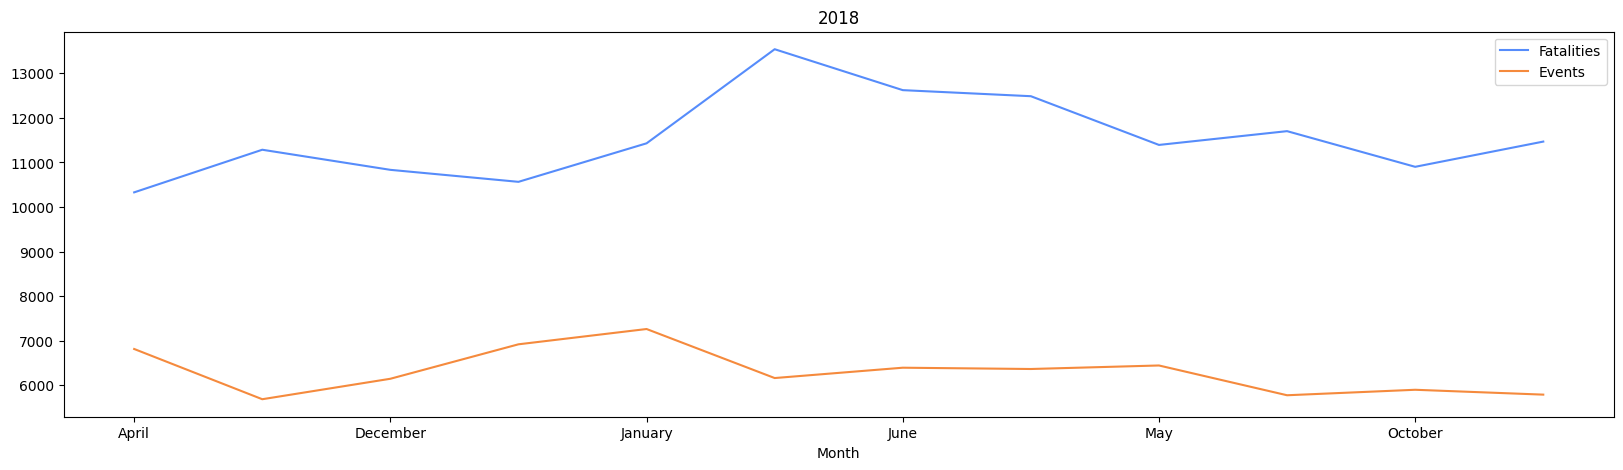

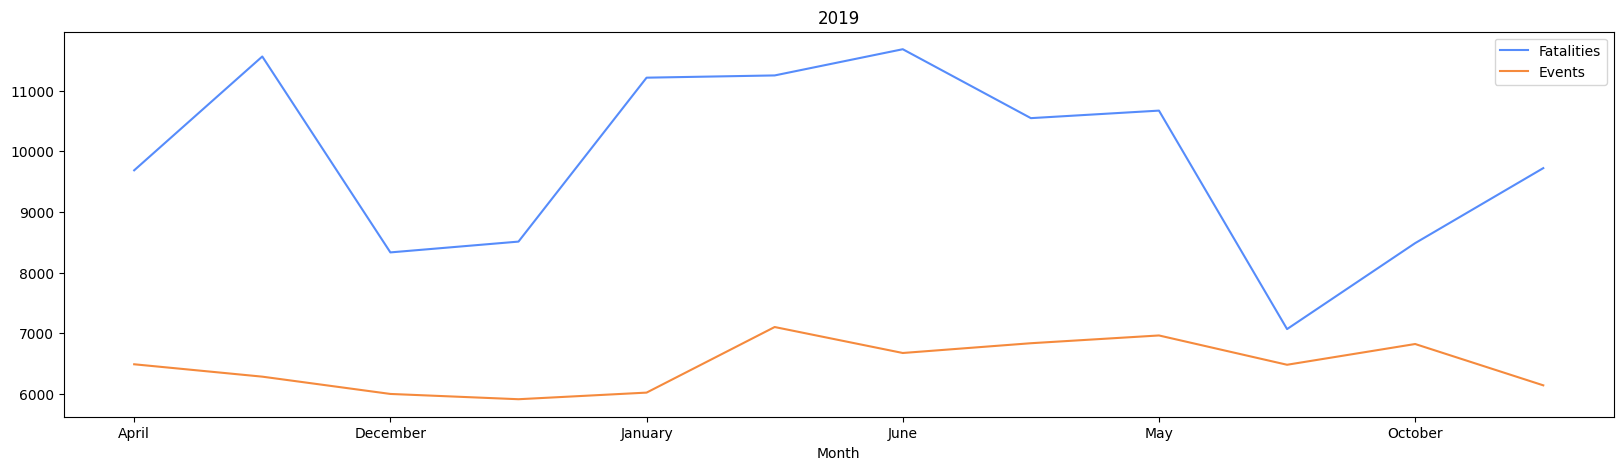

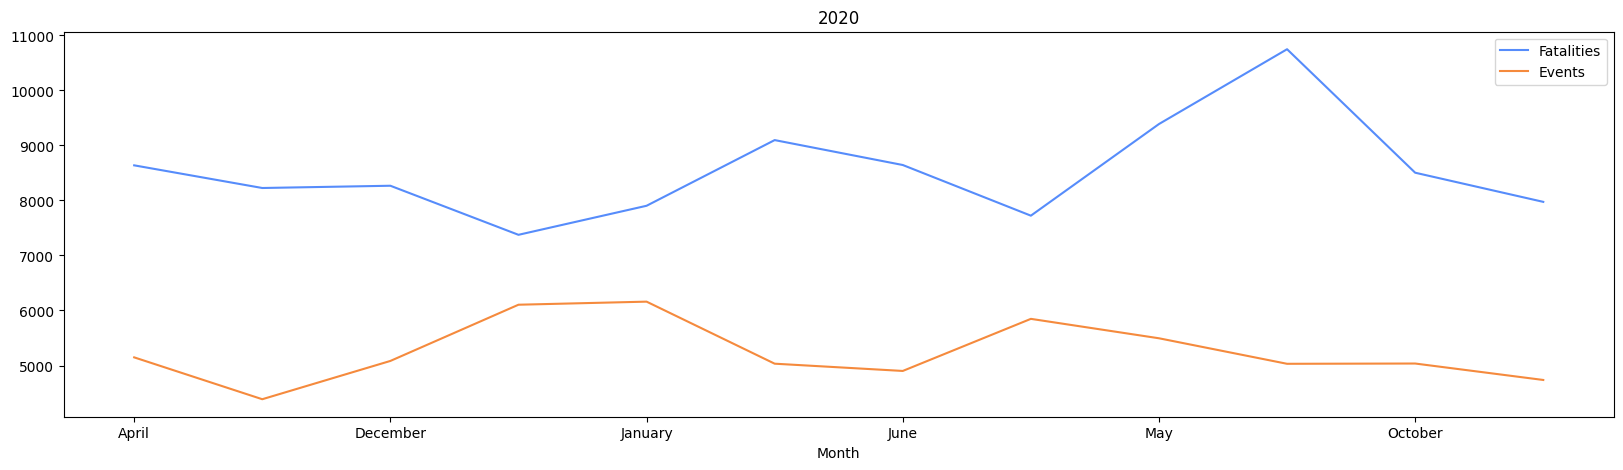

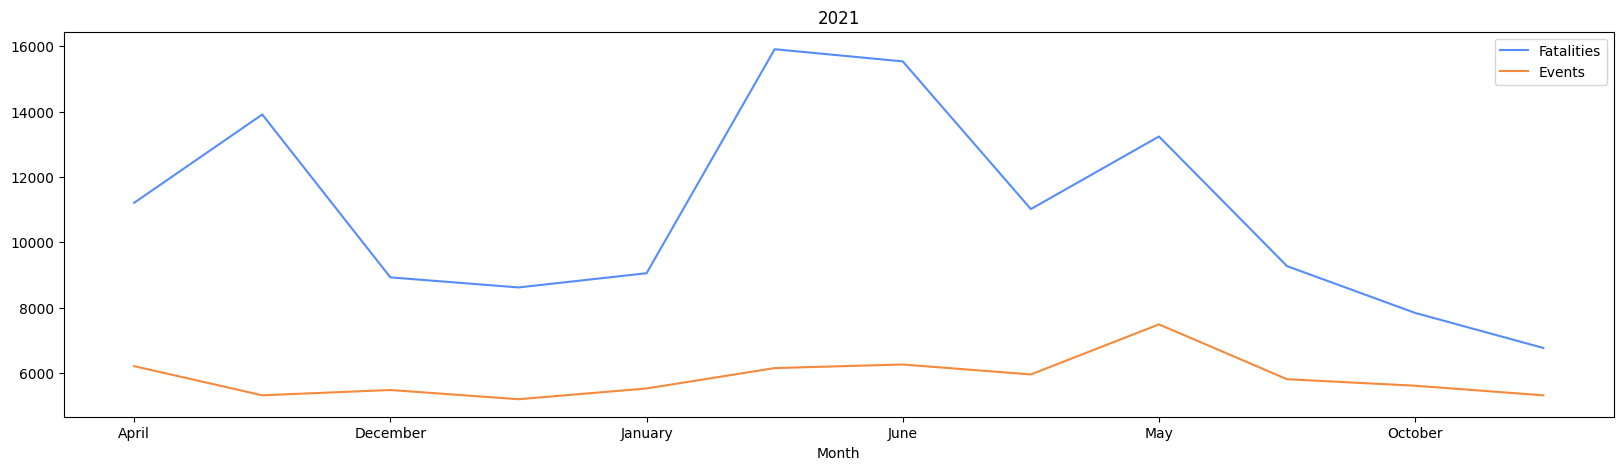

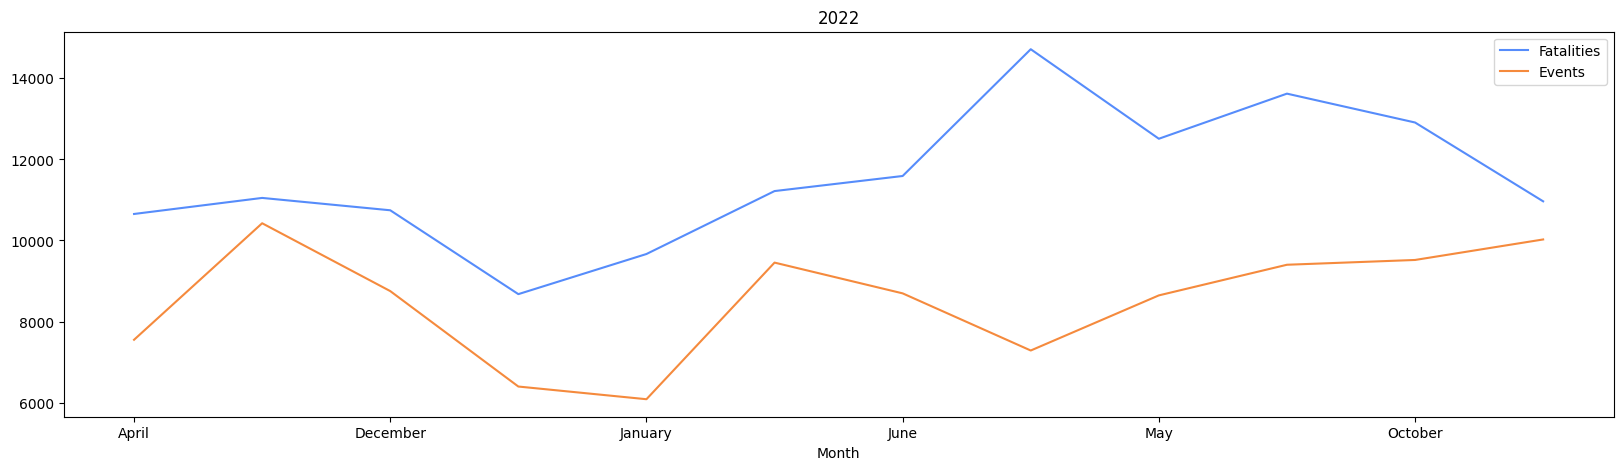

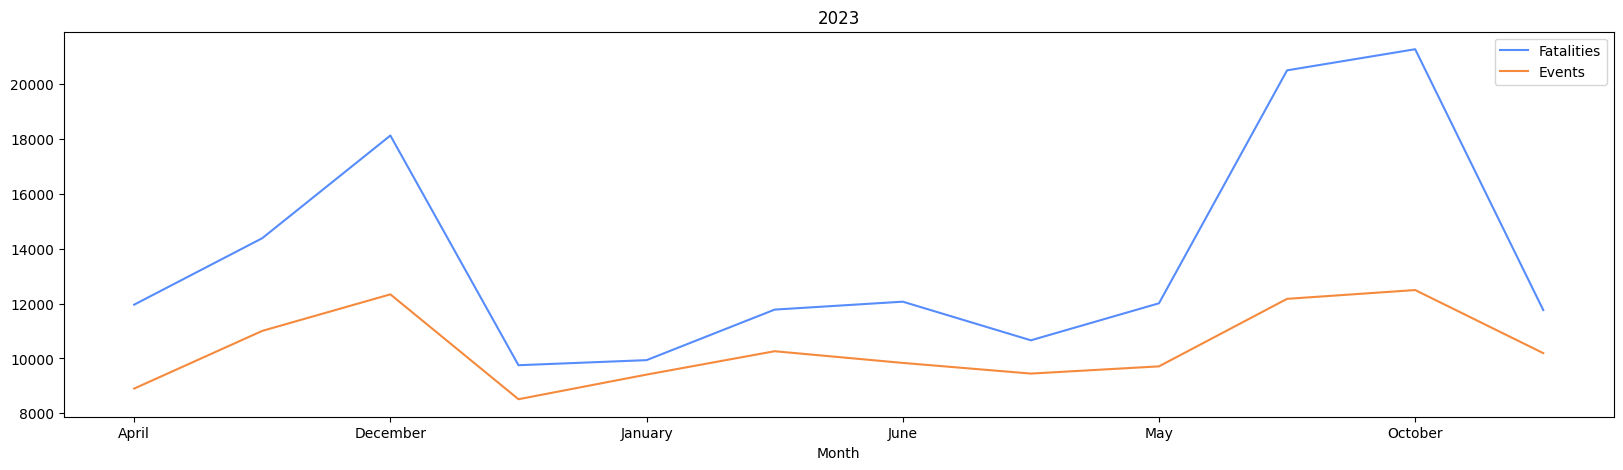

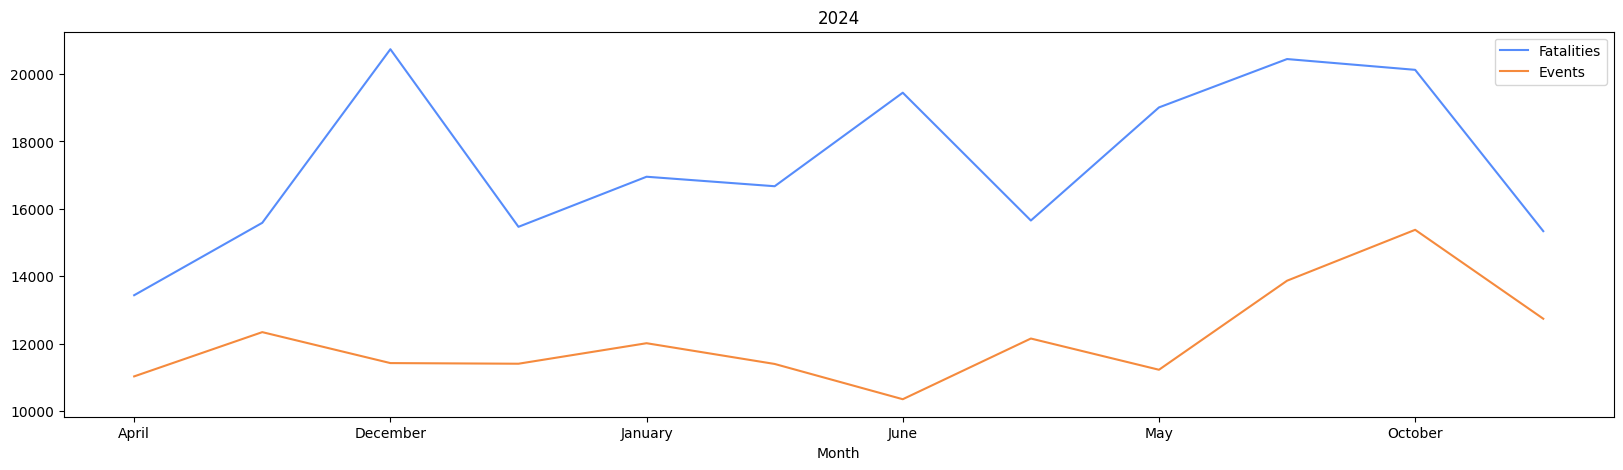

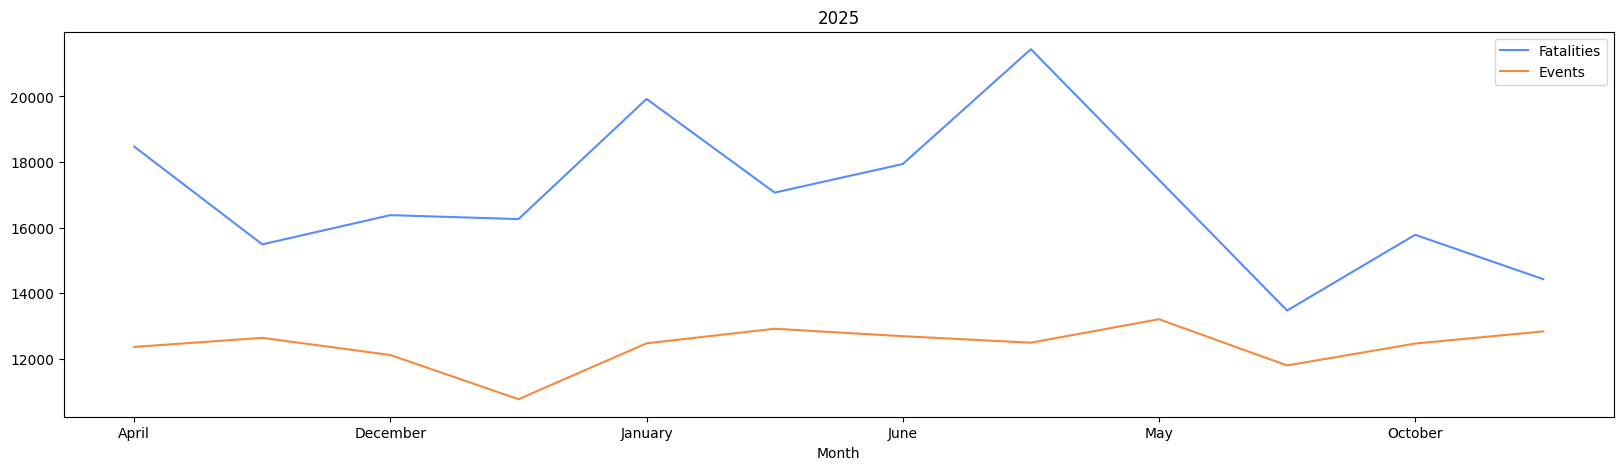

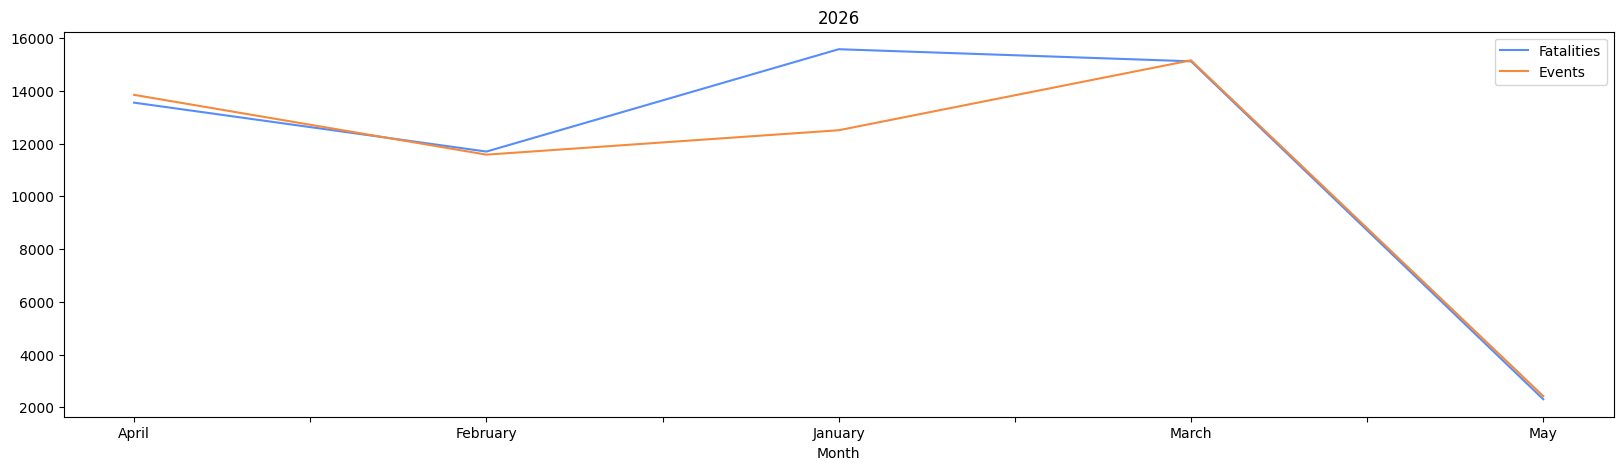

In [12]:
for y in sorted(df_month_grouped.Year.unique()):
    df_month_grouped[df_month_grouped["Year"] == y].groupby("Month")[['Fatalities', 'Events']].sum().plot(kind="line", figsize=(20, 5), title=y)
    plt.show()

In [13]:
# 1. Aggregate the total fatalities for every Admin1 region per Country and Year
df_admin1_totals = df.groupby(['Country', 'Year', 'Admin1', 'Admin2'])['Fatalities'].sum().reset_index()

# 2. Find the index numbers of the rows with the highest fatalities for each Country/Year block
max_indices = df_admin1_totals.groupby(['Country', 'Year'])['Fatalities'].idxmax()

# 3. Use those index numbers to slice the exact rows out of the aggregated DataFrame
df_highest_fatalities = df_admin1_totals.loc[max_indices]

In [14]:
df_highest_fatalities

,Country,Year,Admin1,Admin2,Fatalities
260,Afghanistan,2017,Nangarhar,Achin,1880
509,Afghanistan,2018,Ghazni,Ghazni,1827
1173,Afghanistan,2019,Urozgan,Tirinkot,1443
1390,Afghanistan,2020,Kandahar,Maiwand,716
1731,Afghanistan,2021,Helmand,Lashkargah,1908
...,...,...,...,...,...
83932,Yemen,2022,Marib,Marib,577
84036,Yemen,2023,Ad Dali,Qaatabah,372
84369,Yemen,2024,Ad Dali,Qaatabah,414
84702,Yemen,2025,Ad Dali,Qaatabah,236


In [15]:

# 1. Aggregate both required metrics to the Admin1 level
df_admin1_rates = df.groupby(['Country', 'Year', 'Admin1'])[['Fatalities', 'Events']].sum().reset_index()

# 2. Calculate the rate safely to prevent 'inf' values
df_admin1_rates['Fatality_Rate'] = np.where(
    df_admin1_rates['Events'] == 0,
    0,
    df_admin1_rates['Fatalities'] / df_admin1_rates['Events']
)

# 3. Extract the rows with the highest calculated rate
max_rate_indices = df_admin1_rates.groupby(['Country', 'Year'])['Fatality_Rate'].idxmax()
df_highest_rate = df_admin1_rates.loc[max_rate_indices]

In [16]:
df_highest_rate

,Country,Year,Admin1,Fatalities,Events,Fatality_Rate
31,Afghanistan,2017,Urozgan,2542,410,6.200000
46,Afghanistan,2018,Jowzjan,1057,175,6.040000
73,Afghanistan,2019,Daykundi,444,68,6.529412
107,Afghanistan,2020,Daykundi,453,68,6.661765
146,Afghanistan,2021,Helmand,4350,625,6.960000
...,...,...,...,...,...,...
8831,Yemen,2022,Al Mahwit,3,1,3.000000
8851,Yemen,2023,Al Jawf,115,101,1.138614
8869,Yemen,2024,Ad Dali,696,452,1.539823
8897,Yemen,2025,Al Mahwit,9,5,1.800000


In [17]:

# 1. Define the explicit macro-region mapping dictionary
region_map = {
    'Burundi': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa',
    'Central African Republic': 'Sub-Saharan Africa', 'Democratic Republic of Congo': 'Sub-Saharan Africa',
    'Ethiopia': 'Sub-Saharan Africa', 'Somalia': 'Sub-Saharan Africa',
    'South Sudan': 'Sub-Saharan Africa', 'Sudan': 'Sub-Saharan Africa',
    'Burkina Faso': 'Sub-Saharan Africa', 'Chad': 'Sub-Saharan Africa',
    'Mali': 'Sub-Saharan Africa', 'Niger': 'Sub-Saharan Africa',
    'Nigeria': 'Sub-Saharan Africa', 'Mozambique': 'Sub-Saharan Africa',
    'Lebanon': 'Middle East & North Africa', 'Palestine': 'Middle East & North Africa',
    'Syria': 'Middle East & North Africa', 'Yemen': 'Middle East & North Africa',
    'Afghanistan': 'Asia & Pacific', 'Myanmar': 'Asia & Pacific',
    'Colombia': 'Latin America & Caribbean', 'Haiti': 'Latin America & Caribbean',
    'Venezuela': 'Latin America & Caribbean',
    'Ukraine': 'Eastern Europe'
}

# 2. Vectorized mapping operation to create the new column
df['Macro_Region'] = df['Country'].map(region_map)

# 3. Handle potential missing values safely
df['Macro_Region'] = df['Macro_Region'].fillna('Other')

# Now you can aggregate or plot by Macro_Region instead of individual countries
region_trends = df.groupby(['Macro_Region', 'Year'])[['Fatalities', 'Events']].sum().reset_index()
region_trends

,Macro_Region,Year,Fatalities,Events
0,Asia & Pacific,2010,268,149
1,Asia & Pacific,2011,1430,447
2,Asia & Pacific,2012,995,493
3,Asia & Pacific,2013,470,518
4,Asia & Pacific,2014,500,435
...,...,...,...,...
72,Sub-Saharan Africa,2022,52162,21582
73,Sub-Saharan Africa,2023,64467,24555
74,Sub-Saharan Africa,2024,66775,26870
75,Sub-Saharan Africa,2025,75151,29846


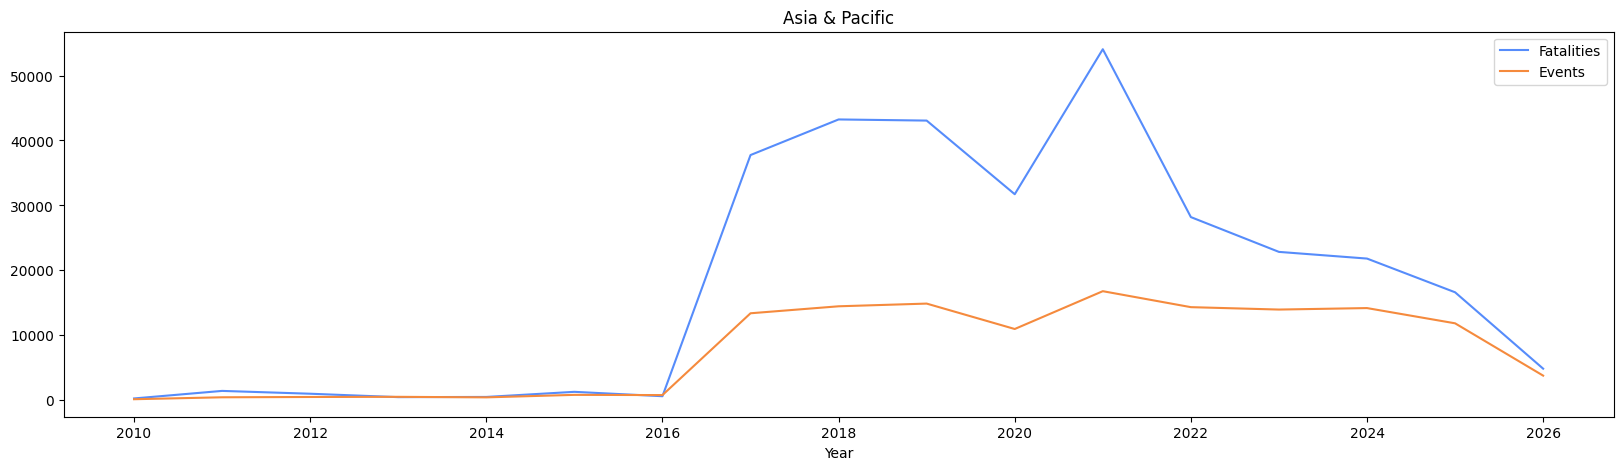

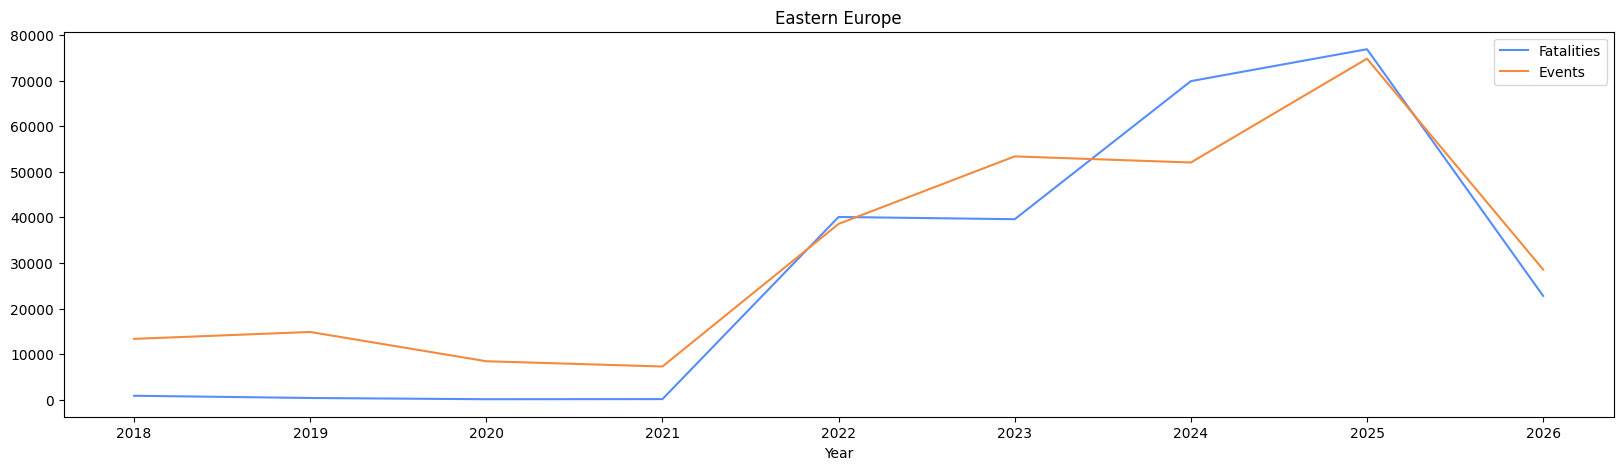

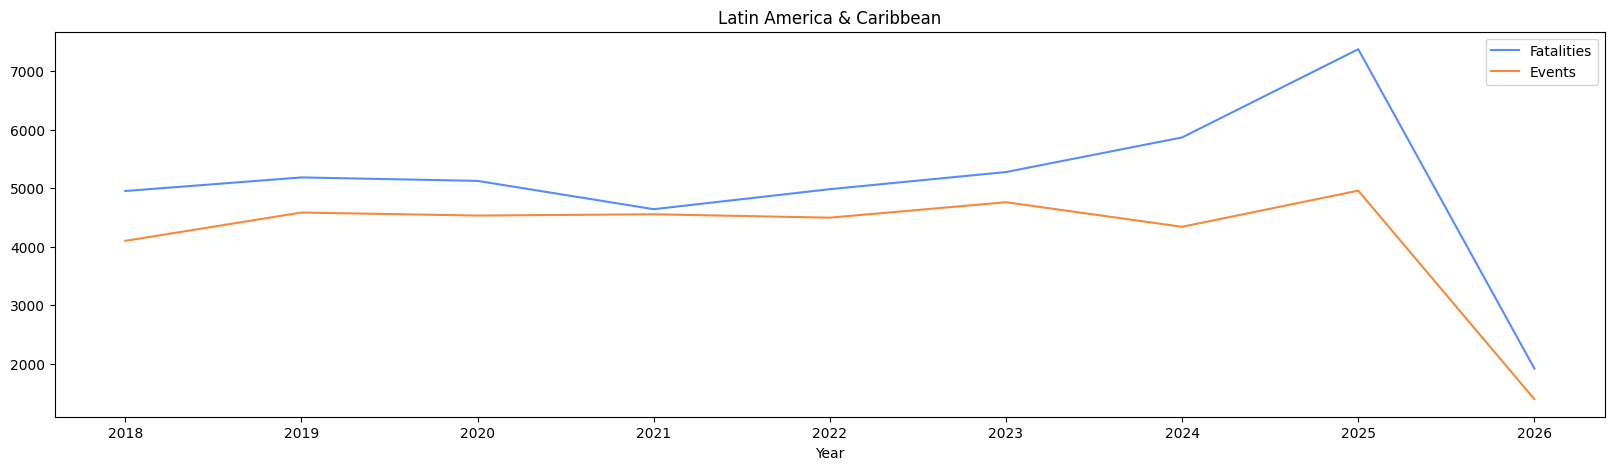

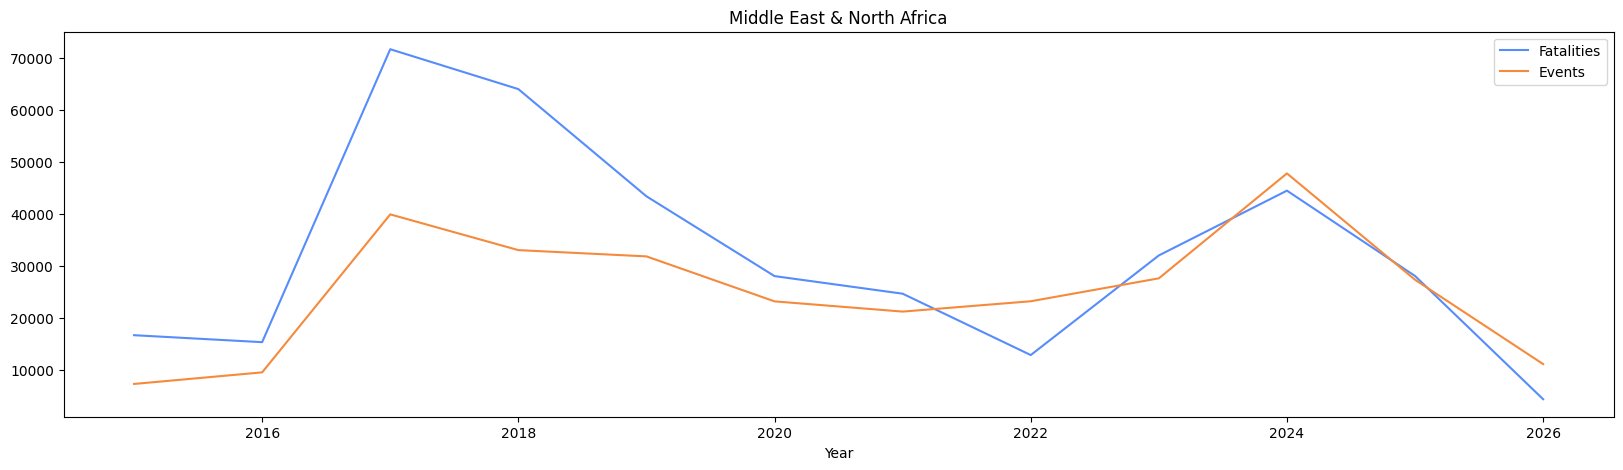

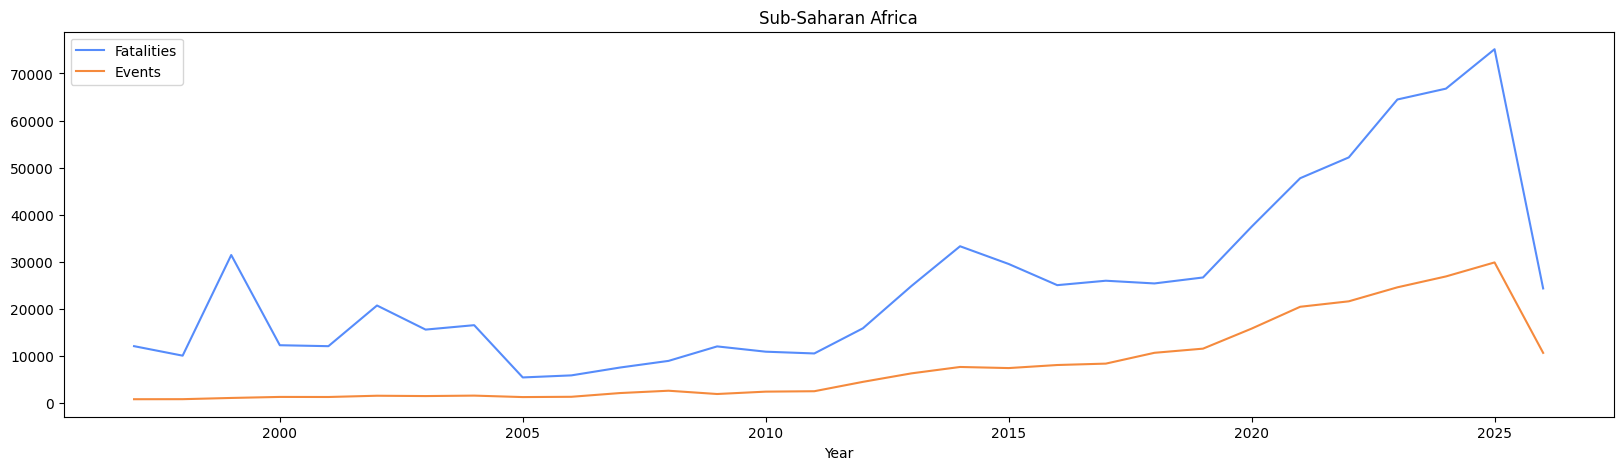

In [18]:
for r in sorted(region_trends.Macro_Region.unique()):
    region_trends[region_trends["Macro_Region"] == r].plot(kind="line", figsize=(20, 5), title=r, x="Year", y=["Fatalities", "Events"])
    plt.show()

In [19]:
import pandas as pd
import numpy as np

# 1. Map string months to integers to build a valid datetime index
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}
df['Month_Num'] = df['Month'].map(month_map)

# 2. Create a unified datetime column
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month_Num'].astype(str) + '-01')

# 3. Sort chronologically within the spatial hierarchy.
# SPREADSHEET ORDER IS NOT GUARANTEED. Sorter execution is strictly mandatory.
df = df.sort_values(by=['Country', 'Admin1', 'Admin2', 'Date']).reset_index(drop=True)

# 4. Calculate Velocity (Month-over-Month percentage change in Events)
# Use groupby to isolate each Admin2 region so data from region A does not bleed into region B
df['MoM_Velocity'] = df.groupby(['Country', 'Admin1', 'Admin2'])['Events'].pct_change()

# 5. Calculate Volatility (3-Month Rolling Variance of Events)
# transform() keeps the index aligned with your original DataFrame
df['Rolling_Volatility'] = df.groupby(['Country', 'Admin1', 'Admin2'])['Events'].transform(
    lambda x: x.rolling(window=3, min_periods=1).var()
)

# 6. Replace infinite values caused by division-by-zero (e.g., going from 0 events to 1 event)
df['MoM_Velocity'] = df['MoM_Velocity'].replace([np.inf, -np.inf], np.nan).fillna(0)
df['Rolling_Volatility'] = df['Rolling_Volatility'].fillna(0)

# 7. Filter for Hotspots (Regions with high velocity AND high volatility)
hotspots = df[(df['MoM_Velocity'] > 0.5) & (df['Events'] > 5)]
hotspots[['Country', 'Admin1', 'Admin2', 'Date', 'Events', 'MoM_Velocity', 'Rolling_Volatility']].head()

,Country,Admin1,Admin2,Date,Events,MoM_Velocity,Rolling_Volatility
133,Afghanistan,Badakhshan,Argo,2018-09-01,6,5.00,7.000000
271,Afghanistan,Badakhshan,Baharak,2020-10-01,6,5.00,7.000000
572,Afghanistan,Badakhshan,Faiz Abad,2017-08-01,11,1.75,31.000000
574,Afghanistan,Badakhshan,Faiz Abad,2017-10-01,15,6.50,44.333333
581,Afghanistan,Badakhshan,Faiz Abad,2018-05-01,11,1.75,22.333333


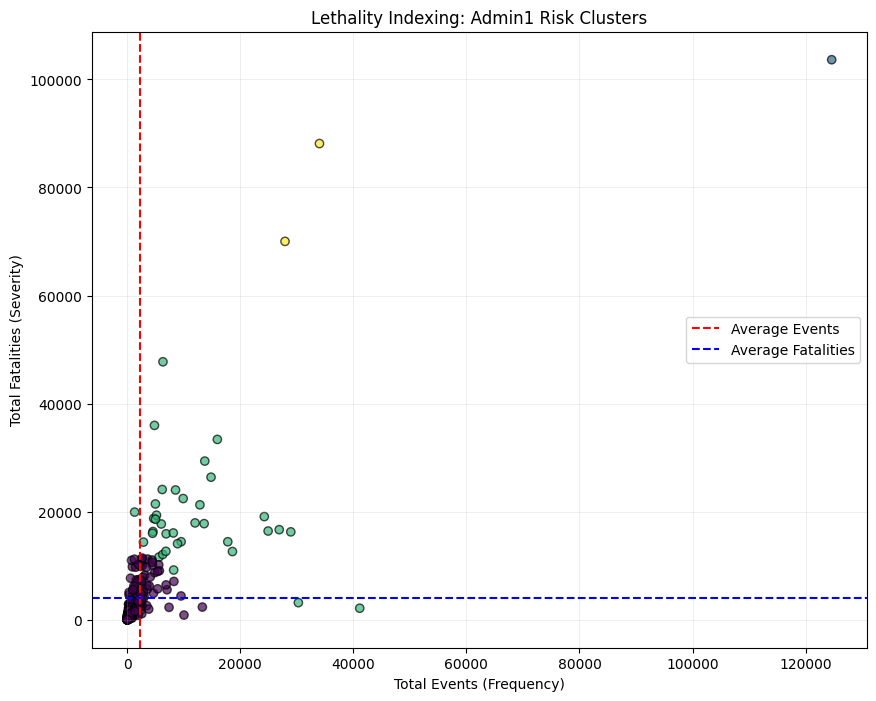

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Aggregate the historical totals to the Admin1 level
# We drop Year and Month to view the overarching systemic risk of the region
df_admin1 = df.groupby(['Country', 'Admin1'])[['Events', 'Fatalities']].sum().reset_index()

# 2. Extract the features for machine learning
X = df_admin1[['Events', 'Fatalities']]

# 3. Standardize the data (CRITICAL STEP)
# This forces both columns to have equal weight in the distance calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Initialize and fit the K-Means algorithm
# We define 4 clusters to map to our Risk Quadrants concept
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_admin1['Risk_Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Visualize the quadrants
plt.figure(figsize=(10, 8))

# Plot each cluster with a different color
scatter = plt.scatter(
    df_admin1['Events'],
    df_admin1['Fatalities'],
    c=df_admin1['Risk_Cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='k'
)

# Add baseline averages to visually divide the chart into literal quadrants
plt.axvline(df_admin1['Events'].mean(), color='red', linestyle='--', label='Average Events')
plt.axhline(df_admin1['Fatalities'].mean(), color='blue', linestyle='--', label='Average Fatalities')

plt.title('Lethality Indexing: Admin1 Risk Clusters')
plt.xlabel('Total Events (Frequency)')
plt.ylabel('Total Fatalities (Severity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the regions assigned to the highest risk cluster (assuming Cluster 3 is highest; verify visually)
# print(df_admin1[df_admin1['Risk_Cluster'] == 3])

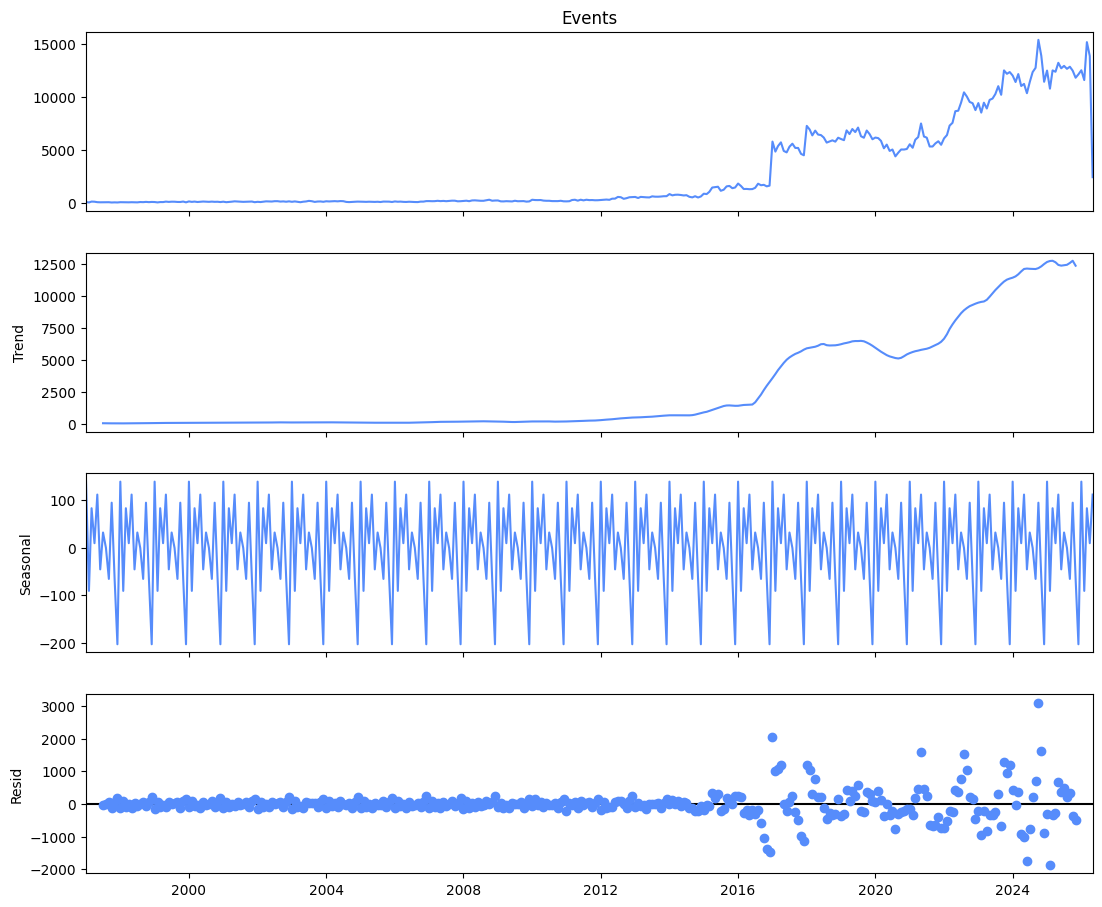

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Aggregate to a single timeline. We will use the national total as an example.
df_national = df.groupby(['Year', 'Month_Num'])['Events'].sum().reset_index()

# 2. Reconstruct the Datetime object using the numeric month mapped previously
df_national['Date'] = pd.to_datetime(df_national['Year'].astype(str) + '-' + df_national['Month_Num'].astype(str) + '-01')

# 3. Set the Date as the strict DataFrame index. Time-series libraries demand this.
df_national = df_national.set_index('Date')

# 4. Force a continuous frequency ('MS' = Month Start).
# This injects a row with 0 for any month completely missing from the raw data.
df_national = df_national.asfreq('MS', fill_value=0)

# 5. Execute the decomposition.
# We apply an additive model governed by the equation:
# $Y_t = T_t + S_t + R_t$ (Data = Trend + Seasonality + Residuals)
decomposition = seasonal_decompose(df_national['Events'], model='additive')

# 6. Visualize the four components
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

In [22]:
# vedere quanti paesi ci sono in ogni anno

# DATASETS MERGE

In [23]:
df_ipc = pd.read_csv("ipc_global_area_long_pcoded.csv", skipinitialspace=True)

In [24]:
country_mapping = {
    "AFG": "Afghanistan",
    "AGO": "Angola",
    "BDI": "Burundi",
    "BEN": "Benin",
    "BFA": "Burkina Faso",
    "BGD": "Bangladesh",
    "CAF": "Repubblica Centrafricana",
    "CIV": "Costa d'Avorio",
    "CMR": "Camerun",
    "COD": "Repubblica Democratica del Congo",
    "CPV": "Capo Verde",
    "DJI": "Gibuti",
    "DOM": "Repubblica Dominicana",
    "ECU": "Ecuador",
    "ETH": "Etiopia",
    "GHA": "Ghana",
    "GIN": "Guinea",
    "GMB": "Gambia",
    "GNB": "Guinea-Bissau",
    "GTM": "Guatemala",
    "HND": "Honduras",
    "HTI": "Haiti",
    "KEN": "Kenya",
    "LBN": "Libano",
    "LBR": "Liberia",
    "LSO": "Lesotho",
    "MDG": "Madagascar",
    "MLI": "Mali",
    "MOZ": "Mozambico",
    "MRT": "Mauritania",
    "MWI": "Malawi",
    "NAM": "Namibia",
    "NER": "Niger",
    "NGA": "Nigeria",
    "PAK": "Pakistan",
    "PSE": "Palestina",
    "SDN": "Sudan",
    "SEN": "Senegal",
    "SLE": "Sierra Leone",
    "SLV": "El Salvador",
    "SOM": "Somalia",
    "SSD": "Sudan del Sud",
    "SWZ": "Eswatini",
    "TCD": "Ciad",
    "TGO": "Togo",
    "TLS": "Timor Est",
    "TZA": "Tanzania",
    "UGA": "Uganda",
    "YEM": "Yemen",
    "ZAF": "Sudafrica",
    "ZMB": "Zambia",
    "ZWE": "Zimbabwe"
}

In [25]:
df_ipc["Country_name"] = df_ipc["Country"].map(country_mapping)

In [28]:
#df_unito = pd.merge(df, df_ipc, on='Country_name', how='inner')

In [32]:
colonna_target = 'From'

# 1. Conversione obbligatoria in datetime specificando il formato esatto dell'immagine
df_ipc[colonna_target] = pd.to_datetime(df_ipc[colonna_target], format='%d/%m/%Y')

# 2. Creazione delle nuove colonne estraendo gli attributi numerici
df_ipc['Month'] = df_ipc[colonna_target].dt.month_name()
df_ipc['Year'] = df_ipc[colonna_target].dt.year

In [37]:
# 1. Correzione sistematica dei prefissi noti (Ciad e Niger)
# Sostituisce i codici che iniziano per 'TD' con 'TCD' e 'NER' con 'NE'
df["Admin1 Pcode"] = df["Admin1 Pcode"].str.replace(r'^TD', 'TCD', regex=True)
df["Admin1 Pcode"] = df["Admin1 Pcode"].str.replace(r'^NER', 'NE', regex=True)

# 2. Creazione di un dizionario per i codici con formati diversi (Camerun e Nigeria)
# NOTA: Devi compilare i valori esatti in base a come vuoi aggregare/disaggregare le regioni.
# Questo è uno schema di esempio per allineare le lunghezze delle stringhe:
mappatura_specifica = {
    # Esempi Camerun (da mappare secondo i tuoi dati geografici reali)
    'CM00': 'CM001',
    'CM01': 'CM002',

    # Esempi Nigeria (se NG00 in df rappresenta un'intera macro-regione,
    # dovrai decidere a quale stato specifico mapparlo o come gestirlo)
    'NG00': 'NG001',
    'NG01': 'NG010',
    'NG02': 'NG020',
    'NG03': 'NG030'
}

# Applica la mappatura manuale
df["Admin1 Pcode"] = df["Admin1 Pcode"].replace(mappatura_specifica)

# 3. Gestione dei NaN (se necessario)
# Se vuoi che i NaN siano formattati in modo coerente
df["Admin1 Pcode"] = df["Admin1 Pcode"].fillna(np.nan)
# Ottieni i valori unici del dataframe di destinazione
valori_validi_ipc = df_ipc["adm1_pcode"].dropna().unique()

# Trova i codici in df che NON sono presenti in df_ipc
codici_orfani = df[~df["Admin1 Pcode"].isin(valori_validi_ipc)]["Admin1 Pcode"].dropna().unique()

print("Codici in df che non hanno corrispondenza in df_ipc:")
print(codici_orfani)

Codici in df che non hanno corrispondenza in df_ipc:
['BF46' 'BF52' 'BF56' 'BDI001' 'BDI017' 'BDI002' 'BDI003' 'BDI004'
 'BDI005' 'BDI006' 'BDI007' 'BDI008' 'BDI009' 'BDI010' 'BDI011' 'BDI012'
 'BDI013' 'BDI014' 'BDI018' 'BDI015' 'BDI016' 'TCD18' 'CO91' 'CO05' 'CO81'
 'CO08' 'CO11' 'CO13' 'CO15' 'CO17' 'CO18' 'CO85' 'CO19' 'CO20' 'CO27'
 'CO23' 'CO25' 'CO94' 'CO95' 'CO41' 'CO44' 'CO47' 'CO50' 'CO52' 'CO54'
 'CO86' 'CO63' 'CO66' 'CO88' 'CO68' 'CO70' 'CO73' 'CO76' 'CO97' 'CO99'
 'ET14' 'ET06' 'ET15' 'ET12' 'ET13' 'MMR017' 'MMR007' 'MMR008' 'MMR004'
 'MMR001' 'MMR002' 'MMR003' 'MMR009' 'MMR010' 'MMR011' 'MMR018' 'MMR012'
 'MMR005' 'MMR016' 'MMR015' 'MMR014' 'MMR006' 'MMR013' 'PS01' 'SY08'
 'SY02' 'SY11' 'SY13' 'SY01' 'SY12' 'SY09' 'SY05' 'SY04' 'SY07' 'SY06'
 'SY14' 'SY03' 'SY10' 'UA71' 'UA74' 'UA73' 'UA01' 'UA12' 'UA14' 'UA26'
 'UA63' 'UA65' 'UA68' 'UA35' 'UA32' 'UA80' 'UA44' 'UA46' 'UA48' 'UA51'
 'UA53' 'UA56' 'UA59' 'UA61' 'UA05' 'UA07' 'UA21' 'UA23' 'UA18' 'VE02'
 'VE03' 'VE04' 'VE05'

In [41]:

# 1. Correzione dei prefissi noti (come applicato per Admin1)
df["Admin2 Pcode"] = df["Admin2 Pcode"].str.replace(r'^TD', 'TCD', regex=True)
df["Admin2 Pcode"] = df["Admin2 Pcode"].str.replace(r'^NER', 'NE', regex=True)

# 2. Creazione di un set per una ricerca efficiente O(1) in df_ipc
valid_ipc_codes = set(df_ipc["adm2_pcode"].dropna())

# 3. Funzione di mappatura gerarchica
def map_admin2_pcode(pcode):
    if pd.isna(pcode):
        return np.nan

    # Tentativo 1: Match esatto (entrambi sono a livello Admin2)
    if pcode in valid_ipc_codes:
        return pcode

    # Tentativo 2: Troncamento a 4 caratteri (df_ipc ha solo il livello Admin1 per questa regione)
    candidate_4 = pcode[:4]
    if candidate_4 in valid_ipc_codes:
        return candidate_4

    # Tentativo 3: Troncamento a 5 caratteri (variante per codici con prefissi diversi)
    candidate_5 = pcode[:5]
    if candidate_5 in valid_ipc_codes:
        return candidate_5

    # Nessuna corrispondenza trovata
    return pcode

# 4. Applicazione della funzione per allineare i valori
df["Admin2 Pcode"] = df["Admin2 Pcode"].apply(map_admin2_pcode)

# 5. Estrazione degli errori residui per analisi forzata
codici_orfani = df[~df["Admin2 Pcode"].isin(valid_ipc_codes)]["Admin2 Pcode"].dropna().unique()

print(f"Errori residui (Codici in df senza corrispondenza in df_ipc): {len(codici_orfani)}")
print(codici_orfani)

Errori residui (Codici in df senza corrispondenza in df_ipc): 2105
['AF2111' 'AF2104' 'AF2108' ... 'YE2315' 'YE2305' 'YE1523']


In [45]:
df.rename(columns={'Country': 'Country_name', 'Admin1 Pcode': 'adm1_pcode', 'Admin2 Pcode': 'adm2_pcode'}, inplace=True)

In [46]:
df_unito = pd.merge(df, df_ipc, on=['Country_name','adm1_pcode','adm2_pcode',"Year", "Month"], how='inner')

In [47]:
df_unito

,Country_name,Admin1,Admin2,ISO3,adm2_pcode,adm1_pcode,Month,Year,Events,Fatalities,...,Country,Total country population,Level 1,Area,Validity period,From,To,Phase,Number,Percentage
0,Afghanistan,Badakhshan,Arghanj Khwah,AFG,AF17,AF17,August,2017,0,0,...,AFG,29724323,NaN,Badakhshan,current,2017-08-01,30/11/2017,3+,344147,0.35
1,Afghanistan,Badakhshan,Arghanj Khwah,AFG,AF17,AF17,August,2018,1,5,...,AFG,31575018,NaN,Badakhshan,current,2018-08-01,31/10/2018,3+,585961,0.60
2,Afghanistan,Badakhshan,Arghanj Khwah,AFG,AF17,AF17,November,2018,3,30,...,AFG,31575018,NaN,Badakhshan,first projection,2018-11-01,28/02/2019,3+,503801,0.70
3,Afghanistan,Badakhshan,Arghanj Khwah,AFG,AF17,AF17,August,2019,0,0,...,AFG,32225560,NaN,Badakhshan,current,2019-08-01,31/10/2019,3+,621395,0.60
4,Afghanistan,Badakhshan,Arghanj Khwah,AFG,AF17,AF17,November,2019,0,0,...,AFG,32225560,NaN,Badakhshan,first projection,2019-11-01,31/03/2020,3+,724961,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30811,Yemen,Taizz,Sharab As Salam,YEM,YE1502,YE15,October,2020,0,0,...,YEM,30041712,Taizz,Shara'b as salam,current,2020-10-01,31/12/2020,3+,72500,0.45
30812,Yemen,Taizz,Sharab As Salam,YEM,YE1502,YE15,January,2021,0,0,...,YEM,30041712,Taizz,Shara'b as salam,first projection,2021-01-01,30/06/2021,3+,88500,0.55
30813,Yemen,Taizz,Sharab As Salam,YEM,YE1502,YE15,October,2022,0,0,...,YEM,31900000,Taizz,Shara'b as salam,first projection,2022-10-01,31/12/2022,3+,105500,0.60
30814,Yemen,Taizz,Sharab As Salam,YEM,YE1502,YE15,May,2025,0,0,...,YEM,34879018,Taizz,Shara'b as salam,current,2025-05-01,31/08/2025,3+,89077,0.50


In [49]:
df_unito.isna().sum()

Country_name                   0
Admin1                         0
Admin2                         0
ISO3                           0
adm2_pcode                     0
adm1_pcode                     0
Month                          0
Year                           0
Events                         0
Fatalities                     0
Macro_Region                   0
Month_Num                      0
Date                           0
MoM_Velocity                   0
Rolling_Volatility             0
Date of analysis               0
Country                        0
Total country population       0
Level 1                     9892
Area                           0
Validity period                0
From                           0
To                             0
Phase                          0
Number                         0
Percentage                     0
dtype: int64